# 09 - XGBoost + Bayesian Optimization for CRD Mortality Prediction

This notebook trains XGBoost models with Bayesian hyperparameter optimization to predict county-level CRD mortality rates. Four models are trained: All Features, Top 20, Top 10, and Top 5 (selected by SHAP importance). GroupShuffleSplit and GroupKFold prevent county-level data leakage throughout.

## 1. Environment Check

In [75]:
# Force clean install of compatible versions
#%pip uninstall -y scikit-optimize
#%pip install -q --no-cache-dir "scikit-optimize>=0.9.0"

import numpy as np
print(f"NumPy version: {np.__version__}")
try:
    import skopt
    print(f"scikit-optimize version: {skopt.__version__}")
except:
    print("scikit-optimize not yet loaded")

NumPy version: 1.26.4
scikit-optimize version: 0.10.2


## 2. Imports

In [76]:
import os
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.model_selection import GroupShuffleSplit, GroupKFold, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

from scipy.stats import pearsonr
from skopt import BayesSearchCV
from skopt.space import Real, Integer

import shap
import warnings
warnings.filterwarnings('ignore')

## 3. Output Directory and Figure Settings

In [77]:
output_dir = '../data/outputs/modeling/xgboost/'
os.makedirs(output_dir, exist_ok=True)

SINGLE_COL_WIDTH = 3.27
DOUBLE_COL_WIDTH = 6.85
DPI = 600
FONT_SIZE = 11

plt.rcParams['font.size'] = FONT_SIZE
plt.rcParams['font.family'] = 'Arial'
sns.set_palette('husl')

print(f" Output directory created: {output_dir}")
print(f" Figure specifications: {DOUBLE_COL_WIDTH}in width, {DPI} DPI")

 Output directory created: ../data/outputs/modeling/xgboost/
 Figure specifications: 6.85in width, 600 DPI


## 4. Load and Prepare Data

### 4.1 Load Dataset

In [78]:
df = pd.read_csv('../data/combined_final/final_combined_all_variables_reduced.csv')

print("=" * 70)
print("DATASET LOADED")
print("=" * 70)
print(f"Shape: {df.shape}")
print(f"  - Rows: {df.shape[0]:,}")
print(f"  - Columns: {df.shape[1]}")
print(f"  - Years: {sorted(df['Year'].unique())}")
print(f"\nColumns: {list(df.columns)}")

DATASET LOADED
Shape: (24487, 48)
  - Rows: 24,487
  - Columns: 48
  - Years: [2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019]

Columns: ['County', 'State', 'CRD Mortality Rate', 'Poverty Rate', "Bachelor's Degree or Higher (%)", 'Disability Rate', 'Total Population', 'Unemployment Rate', 'Year', 'White Population (%)', 'Hispanic Population (%)', 'Black Population (%)', 'Households with No Vehicle (%)', 'Single Mother Families (%)', 'fips', 'Land-sea Mask', 'Mean Sea Level Pressure', 'Dust Aerosol (0.55-0.9 Μm) Mixing Ratio', 'Dust Aerosol (0.9-20 Μm) Mixing Ratio', 'Hydrophilic Black Carbon Aerosol Mixing Ratio', 'Hydrophobic Black Carbon Aerosol Mixing Ratio', 'Hydrophobic Organic Matter Aerosol Mixing Ratio', 'Sea Salt Aerosol (0.5-5 Μm) Mixing Ratio', 'Sea Salt Aerosol (5-20 Μm) Mixing Ratio', 'Sulphate Aerosol Mixing Ratio', 'Leaf Area Index, High Vegetation', 'Leaf Area Index, Low Vegetation', 'Snow Depth', '10m Wind Speed', 'Wet Bulb Temperature', 'FoT Carbonmonoxide Above75ᵗʰ P

### 4.2 Scale Target Variable

In [79]:
print("=" * 70)
print("SCALING TARGET VARIABLE")
print("=" * 70)
print(f"Original CRD Mortality Rate:")
print(f"  Min:  {df['CRD Mortality Rate'].min():.6f}")
print(f"  Max:  {df['CRD Mortality Rate'].max():.6f}")
print(f"  Mean: {df['CRD Mortality Rate'].mean():.6f}")

df['CRD Mortality Rate'] = df['CRD Mortality Rate'] * 100000

print(f"\nScaled CRD Mortality Rate (per 100,000 population):")
print(f"  Min:  {df['CRD Mortality Rate'].min():.2f}")
print(f"  Max:  {df['CRD Mortality Rate'].max():.2f}")
print(f"  Mean: {df['CRD Mortality Rate'].mean():.2f}")
print(f"\n Target variable scaled by 100,000 for numerical stability")
print("=" * 70)

SCALING TARGET VARIABLE
Original CRD Mortality Rate:
  Min:  0.000181
  Max:  0.001873
  Mean: 0.000753

Scaled CRD Mortality Rate (per 100,000 population):
  Min:  18.15
  Max:  187.26
  Mean: 75.28

 Target variable scaled by 100,000 for numerical stability


### 4.3 Separate Features and Target

In [80]:
X = df.drop(columns=['County', 'State', 'Year', 'fips', 'CRD Mortality Rate'])
y = df['CRD Mortality Rate']
groups = df['fips']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Groups (unique counties): {groups.nunique()}")
print(f"\nNumber of features: {X.shape[1]}")
print(f"\nFeature list:")
for i, col in enumerate(X.columns, 1):
    print(f"  {i:2}. {col}")

Features shape: (24487, 43)
Target shape: (24487,)
Groups (unique counties): 3061

Number of features: 43

Feature list:
   1. Poverty Rate
   2. Bachelor's Degree or Higher (%)
   3. Disability Rate
   4. Total Population
   5. Unemployment Rate
   6. White Population (%)
   7. Hispanic Population (%)
   8. Black Population (%)
   9. Households with No Vehicle (%)
  10. Single Mother Families (%)
  11. Land-sea Mask
  12. Mean Sea Level Pressure
  13. Dust Aerosol (0.55-0.9 Μm) Mixing Ratio
  14. Dust Aerosol (0.9-20 Μm) Mixing Ratio
  15. Hydrophilic Black Carbon Aerosol Mixing Ratio
  16. Hydrophobic Black Carbon Aerosol Mixing Ratio
  17. Hydrophobic Organic Matter Aerosol Mixing Ratio
  18. Sea Salt Aerosol (0.5-5 Μm) Mixing Ratio
  19. Sea Salt Aerosol (5-20 Μm) Mixing Ratio
  20. Sulphate Aerosol Mixing Ratio
  21. Leaf Area Index, High Vegetation
  22. Leaf Area Index, Low Vegetation
  23. Snow Depth
  24. 10m Wind Speed
  25. Wet Bulb Temperature
  26. FoT Carbonmonoxide Above

### 4.4 Train/Test Split (GroupShuffleSplit by County)

In [81]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train = groups.iloc[train_idx]

train_counties = set(groups.iloc[train_idx])
test_counties  = set(groups.iloc[test_idx])
overlap = train_counties.intersection(test_counties)

n_train = X_train.shape[0]
n_test  = X_test.shape[0]

print("=" * 70)
print("TRAIN/TEST SPLIT (GroupShuffleSplit by County)")
print("=" * 70)
print(f"Training set:")
print(f"  - Shape: {X_train.shape}")
print(f"  - Samples: {X_train.shape[0]:,}")
print(f"  - Unique counties: {len(train_counties)}")
print(f"\nTest set:")
print(f"  - Shape: {X_test.shape}")
print(f"  - Samples: {X_test.shape[0]:,}")
print(f"  - Unique counties: {len(test_counties)}")
print(f"\nData leakage check:")
print(f"  - Counties in both train and test: {len(overlap)}")
print(f"  - Status: {' NO LEAKAGE' if len(overlap) == 0 else ' LEAKAGE DETECTED!'}")

TRAIN/TEST SPLIT (GroupShuffleSplit by County)
Training set:
  - Shape: (19583, 43)
  - Samples: 19,583
  - Unique counties: 2448

Test set:
  - Shape: (4904, 43)
  - Samples: 4,904
  - Unique counties: 613

Data leakage check:
  - Counties in both train and test: 0
  - Status:  NO LEAKAGE


## 5. All Features Model

### 5.1 Initialize XGBoost

In [82]:
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    tree_method='hist'
)

print(" XGBoost model initialized")

 XGBoost model initialized


### 5.2 Configure Bayesian Search Space

In [83]:
search_spaces = {
    "n_estimators":      Integer(150, 800),
    "max_depth":         Integer(3, 7),
    "learning_rate":     Real(0.03, 0.25, prior="log-uniform"),
    "subsample":         Real(0.6, 0.9),
    "colsample_bytree":  Real(0.5, 0.85),
    "reg_alpha":         Real(0.05, 8.0, prior="log-uniform"),
    "reg_lambda":        Real(0.5, 8.0, prior="log-uniform"),
    "min_child_weight":  Integer(3, 15),
}

bayes = BayesSearchCV(
    estimator=xgb_model,
    search_spaces=search_spaces,
    n_iter=30,
    cv=GroupKFold(n_splits=5),
    scoring="r2",
    n_jobs=-1,
    random_state=42,
    refit=True,
    verbose=1,
)

print(" Bayesian search configured")
print(f"  - Iterations: 30")
print(f"  - Cross-validation: 5-fold GroupKFold (by county)")
print(f"  - Scoring metric: R²")

 Bayesian search configured
  - Iterations: 30
  - Cross-validation: 5-fold GroupKFold (by county)
  - Scoring metric: R²


### 5.3 Run Bayesian Optimization

In [84]:
print("Starting Bayesian optimization...")
print("This may take 10-15 minutes depending on your hardware.")
print("Using GroupKFold to prevent county-level data leakage.\n")

bayes.fit(X_train, y_train, groups=groups_train)

print("\n" + "=" * 70)
print("OPTIMIZATION COMPLETE")
print("=" * 70)
print(f"Best parameters found:")
for param, value in bayes.best_params_.items():
    print(f"  - {param}: {value}")
print(f"\nBest CV R² (mean over folds): {bayes.best_score_:.4f}")

Starting Bayesian optimization...
This may take 10-15 minutes depending on your hardware.
Using GroupKFold to prevent county-level data leakage.

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 

### 5.4 Generate Predictions

In [85]:
best_model = bayes.best_estimator_

train_predictions = best_model.predict(X_train)
test_predictions  = best_model.predict(X_test)

print(" Predictions generated for training and test sets")

 Predictions generated for training and test sets


### 5.5 Calculate Performance Metrics

In [86]:
train_rmse = np.sqrt(mean_squared_error(y_train, train_predictions))
test_rmse  = np.sqrt(mean_squared_error(y_test,  test_predictions))
train_mae  = mean_absolute_error(y_train, train_predictions)
test_mae   = mean_absolute_error(y_test,  test_predictions)
r2_train   = r2_score(y_train, train_predictions)
r2_test    = r2_score(y_test,  test_predictions)

p = X_train.shape[1]
adj_r2_train = 1 - (1 - r2_train) * ((n_train - 1) / (n_train - p - 1))
adj_r2_test  = 1 - (1 - r2_test)  * ((n_test  - 1) / (n_test  - p - 1))

print("=" * 70)
print("MODEL PERFORMANCE METRICS (ALL FEATURES)")
print("=" * 70)
print(f"\nTraining Set:")
print(f"  R² Score:       {r2_train:.4f}")
print(f"  Adjusted R²:    {adj_r2_train:.4f}")
print(f"  RMSE:           {train_rmse:.2f} per 100,000")
print(f"  MAE:            {train_mae:.2f} per 100,000")
print(f"\nTest Set:")
print(f"  R² Score:       {r2_test:.4f}")
print(f"  Adjusted R²:    {adj_r2_test:.4f}")
print(f"  RMSE:           {test_rmse:.2f} per 100,000")
print(f"  MAE:            {test_mae:.2f} per 100,000")

MODEL PERFORMANCE METRICS (ALL FEATURES)

Training Set:
  R² Score:       0.9679
  Adjusted R²:    0.9679
  RMSE:           3.50 per 100,000
  MAE:            2.65 per 100,000

Test Set:
  R² Score:       0.7550
  Adjusted R²:    0.7529
  RMSE:           9.58 per 100,000
  MAE:            7.35 per 100,000


### 5.6 Save Metrics Table 1

In [87]:
metrics_summary_all = pd.DataFrame({
    'Metric': ['R² Score', 'Adjusted R²', 'RMSE (per 100,000)', 'MAE (per 100,000)', 'Sample Size'],
    'Training Set': [f'{r2_train:.3f}', f'{adj_r2_train:.3f}', f'{train_rmse:.2f}', f'{train_mae:.2f}', f'{len(y_train):,}'],
    'Test Set':     [f'{r2_test:.3f}',  f'{adj_r2_test:.3f}',  f'{test_rmse:.2f}',  f'{test_mae:.2f}',  f'{len(y_test):,}']
})

print("\nTable 1: Model Performance Metrics for All Features")
print("=" * 70)
display(metrics_summary_all)
print("=" * 70)

metrics_summary_all.to_csv(f'{output_dir}table1_metrics_all_features.csv', index=False)
print(f"\n Table saved to: {output_dir}table1_metrics_all_features.csv")


Table 1: Model Performance Metrics for All Features


,Metric,Training Set,Test Set
0,R² Score,0.968,0.755
1,Adjusted R²,0.968,0.753
2,"RMSE (per 100,000)",3.50,9.58
3,"MAE (per 100,000)",2.65,7.35
4,Sample Size,"19,583","4,904"



 Table saved to: ../data/outputs/modeling/xgboost/table1_metrics_all_features.csv


### 5.7 Figure 1: Scatter Plot — All Features

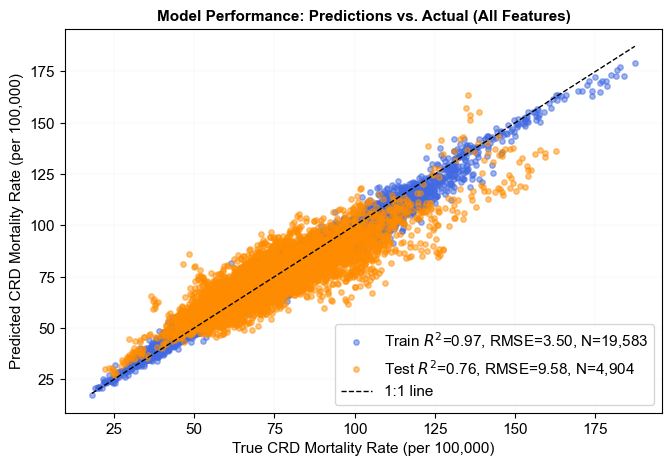

Figure 1: Scatter plot showing predicted vs. actual CRD mortality for all features model.


In [88]:
fig, ax = plt.subplots(figsize=(DOUBLE_COL_WIDTH, DOUBLE_COL_WIDTH * 0.7))

ax.scatter(y_train, train_predictions, color='royalblue',
           label=f'Train $R^2$={r2_train:.2f}, RMSE={train_rmse:.2f}, N={len(y_train):,}',
           alpha=0.5, s=15)
ax.scatter(y_test, test_predictions, color='darkorange',
           label=f'Test $R^2$={r2_test:.2f}, RMSE={test_rmse:.2f}, N={len(y_test):,}',
           alpha=0.5, s=15)
ax.plot([y.min(), y.max()], [y.min(), y.max()],
        linestyle='--', color='black', linewidth=1, label='1:1 line')

ax.set_xlabel('True CRD Mortality Rate (per 100,000)', fontsize=FONT_SIZE)
ax.set_ylabel('Predicted CRD Mortality Rate (per 100,000)', fontsize=FONT_SIZE)
ax.set_title('Model Performance: Predictions vs. Actual (All Features)',
             fontsize=FONT_SIZE, fontweight='bold')
ax.legend(fontsize=11, frameon=True, loc='lower right')
ax.grid(axis='both', linewidth=0.15, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{output_dir}fig1_scatter_performance_all_features.png', dpi=DPI, bbox_inches='tight')
plt.show()
print("Figure 1: Scatter plot showing predicted vs. actual CRD mortality for all features model.")

### 5.8 Figure 2: Q-Q Plot — All Features

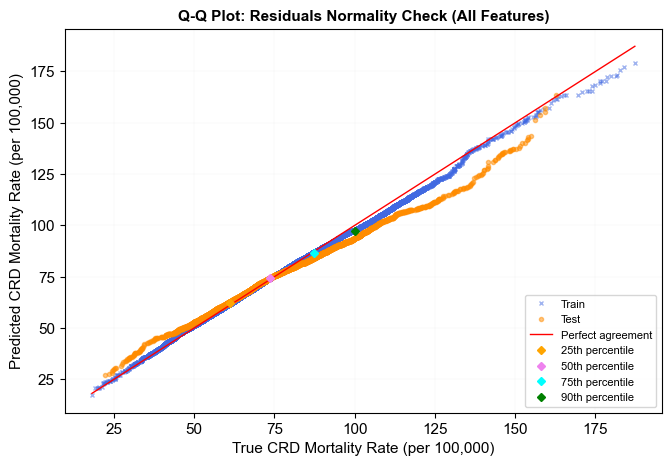

Figure 2: Q-Q plot for all features model.


In [89]:
train_preds_sorted = np.sort(train_predictions)
train_targets_sorted = np.sort(y_train)
test_preds_sorted = np.sort(test_predictions)
test_targets_sorted = np.sort(y_test)

all_predictions = np.concatenate((train_predictions, test_predictions))
all_targets = np.concatenate((y_train, y_test))

fig, ax = plt.subplots(figsize=(DOUBLE_COL_WIDTH, DOUBLE_COL_WIDTH * 0.7))

ax.plot(train_targets_sorted, train_preds_sorted, 'x',
        label='Train', alpha=0.5, color='royalblue', markersize=3)
ax.plot(test_targets_sorted, test_preds_sorted, 'o',
        label='Test', alpha=0.5, color='darkorange', markersize=3)
ax.plot([all_targets.min(), all_targets.max()], [all_targets.min(), all_targets.max()],
        'r', linewidth=1, label='Perfect agreement')

for percentile, color, label in [(25, 'orange', '25th'), (50, 'violet', '50th'),
                                   (75, 'cyan', '75th'), (90, 'green', '90th')]:
    target_pct = np.percentile(np.sort(all_targets), percentile)
    pred_pct   = np.percentile(np.sort(all_predictions), percentile)
    ax.plot(target_pct, pred_pct, marker="D", markersize=4,
            color=color, linestyle='None', label=f"{label} percentile")

ax.set_title('Q-Q Plot: Residuals Normality Check (All Features)',
             fontsize=FONT_SIZE, fontweight="bold")
ax.set_xlabel('True CRD Mortality Rate (per 100,000)', fontsize=FONT_SIZE)
ax.set_ylabel('Predicted CRD Mortality Rate (per 100,000)', fontsize=FONT_SIZE)
ax.grid(axis='both', linewidth=0.15, alpha=0.3)
ax.legend(fontsize=8, frameon=True, loc='lower right')

plt.tight_layout()
plt.savefig(f'{output_dir}fig2_qq_plot_all_features.png', dpi=DPI, bbox_inches='tight')
plt.show()
print("Figure 2: Q-Q plot for all features model.")

### 5.9 Calculate Permutation Importance

In [90]:
perm_importance = permutation_importance(best_model, X_test, y_test,
                                          n_repeats=10, random_state=42)
perm_importance_df = pd.DataFrame({
    'Feature':    X_test.columns,
    'Importance': perm_importance.importances_mean
}).sort_values(by='Importance', ascending=False)

print(f" Permutation importance calculated for {len(perm_importance_df)} features")

 Permutation importance calculated for 43 features


### 5.10 Figure 3: Permutation Importance — All Features

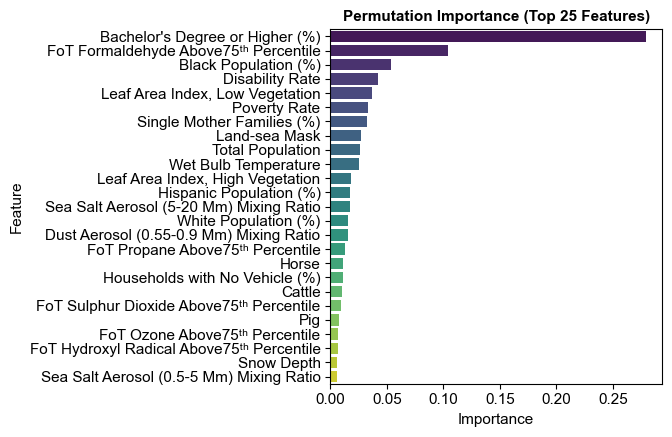

Figure 3: Permutation importance for all features model.


In [91]:
fig, ax = plt.subplots(figsize=(DOUBLE_COL_WIDTH, 4.5))
sns.barplot(x='Importance', y='Feature', data=perm_importance_df.head(25),
            palette='viridis', ax=ax)
ax.set_title('Permutation Importance (Top 25 Features)',
             fontsize=FONT_SIZE, fontweight='bold')
ax.set_xlabel('Importance', fontsize=FONT_SIZE)
ax.set_ylabel('Feature', fontsize=FONT_SIZE)
plt.tight_layout()
plt.savefig(f'{output_dir}fig3_permutation_importance_all_features.png', dpi=DPI, bbox_inches='tight')
plt.show()
print("Figure 3: Permutation importance for all features model.")

### 5.11 Compute SHAP Values

In [92]:
print("Creating SHAP explainer...")
explainer = shap.TreeExplainer(best_model)
print("Computing SHAP values...")
shap_values = explainer.shap_values(X_test)
print(f" SHAP values computed for {X_test.shape[0]:,} test samples")

Creating SHAP explainer...
Computing SHAP values...
 SHAP values computed for 4,904 test samples


### 5.12 Figure 4: SHAP Summary Plot — All Features

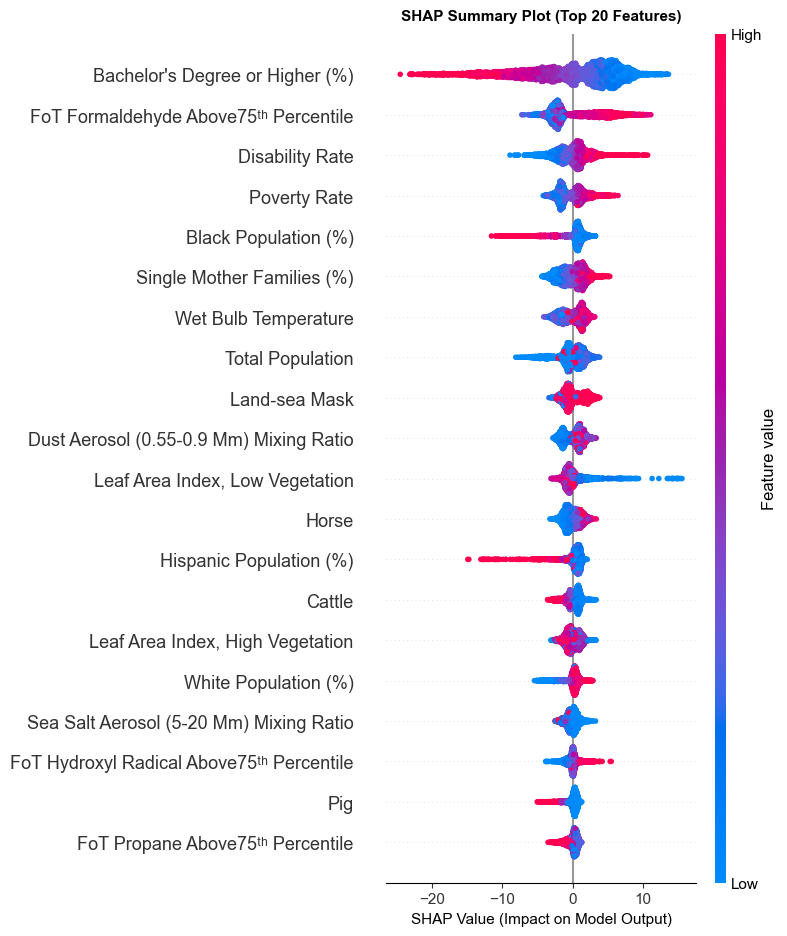

Figure 4: SHAP summary plot for all features model.


In [93]:
plt.figure(figsize=(DOUBLE_COL_WIDTH, 5))
shap.summary_plot(shap_values, X_test, max_display=20, show=False)
plt.title('SHAP Summary Plot (Top 20 Features)',
          fontsize=FONT_SIZE, fontweight='bold', pad=10)
plt.xlabel('SHAP Value (Impact on Model Output)', fontsize=FONT_SIZE)
plt.tight_layout()
plt.savefig(f'{output_dir}fig4_shap_summary_all_features.png', dpi=DPI, bbox_inches='tight')
plt.show()
print("Figure 4: SHAP summary plot for all features model.")

### 5.13 Figure 5: SHAP Bar Plot — All Features

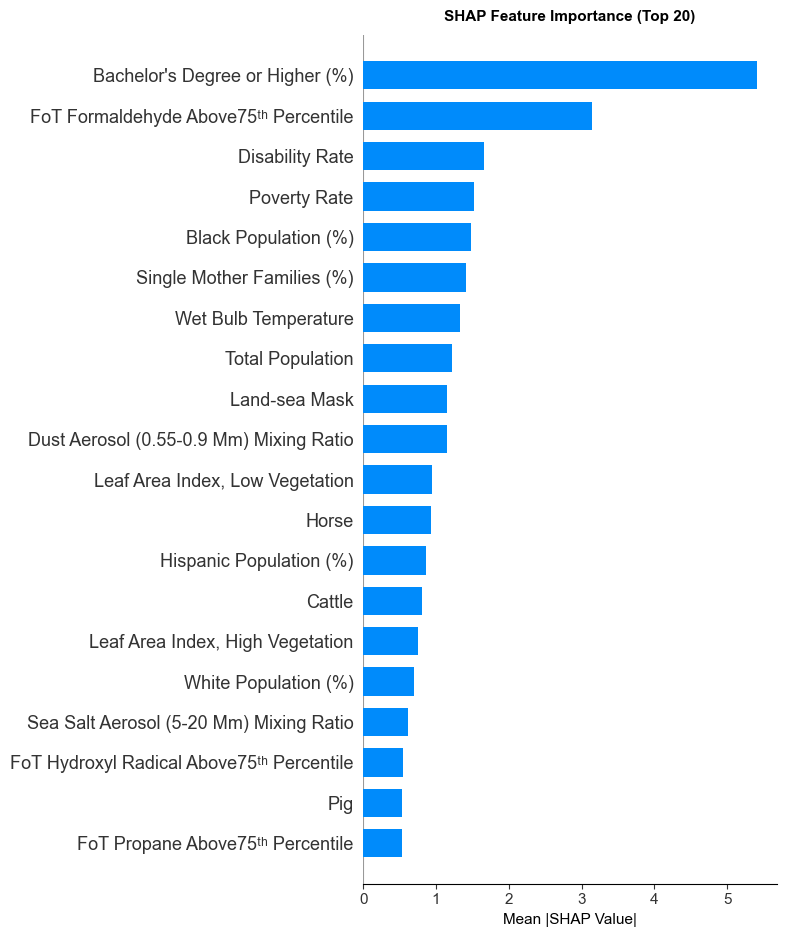

Figure 5: SHAP bar plot for all features model.


In [94]:
plt.figure(figsize=(SINGLE_COL_WIDTH, 4))
shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=20, show=False)
plt.title('SHAP Feature Importance (Top 20)',
          fontsize=FONT_SIZE, fontweight='bold', pad=10)
plt.xlabel('Mean |SHAP Value|', fontsize=FONT_SIZE)
plt.tight_layout()
plt.savefig(f'{output_dir}fig5_shap_bar_all_features.png', dpi=DPI, bbox_inches='tight')
plt.show()
print("Figure 5: SHAP bar plot for all features model.")

### 5.14 Identify Top 3 Features by SHAP

In [95]:
shap_importance = np.abs(shap_values).mean(axis=0)
top_3_indices  = np.argsort(shap_importance)[-3:][::-1]
top_3_features = [X_test.columns[i] for i in top_3_indices]
print(f"Top 3 features for dependence plots: {top_3_features}")

Top 3 features for dependence plots: ["Bachelor's Degree or Higher (%)", 'FoT Formaldehyde Above75ᵗʰ Percentile', 'Disability Rate']


### 5.15 Figure 6: SHAP Dependence Plots — Top 3 Features

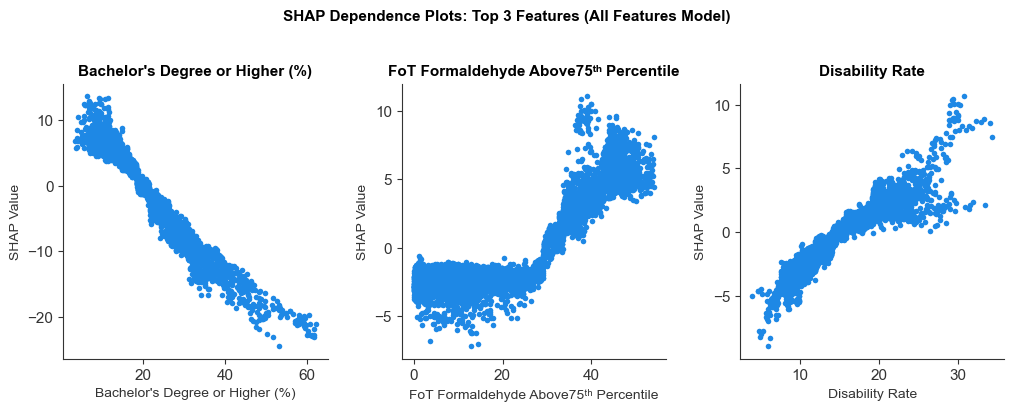

Figure 6: SHAP dependence plots for all features model.


In [96]:
fig, axes = plt.subplots(1, 3, figsize=(DOUBLE_COL_WIDTH * 1.5, 4))

for idx, feature in enumerate(top_3_features):
    shap.dependence_plot(feature, shap_values, X_test,
                         ax=axes[idx], show=False, interaction_index=None)
    axes[idx].set_title(f'{feature}', fontsize=FONT_SIZE, fontweight='bold')
    axes[idx].set_xlabel(feature, fontsize=FONT_SIZE - 1)
    axes[idx].set_ylabel('SHAP Value', fontsize=FONT_SIZE - 1)

plt.suptitle('SHAP Dependence Plots: Top 3 Features (All Features Model)',
             fontsize=FONT_SIZE, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{output_dir}fig6_shap_dependence_all_features.png', dpi=DPI, bbox_inches='tight')
plt.show()
print("Figure 6: SHAP dependence plots for all features model.")

## 6. Top 20 Features Model

### 6.1 Extract Top 20 Features by SHAP Importance

In [97]:
shap_importance_all = np.abs(shap_values).mean(axis=0)
top_20_indices  = np.argsort(shap_importance_all)[-20:][::-1]
top_20_features = [X_test.columns[i] for i in top_20_indices]

print("=" * 70)
print("TOP 20 FEATURES (by SHAP importance)")
print("=" * 70)
for i, feat in enumerate(top_20_features, 1):
    print(f"  {i:2}. {feat}")

X_train_top20 = X_train[top_20_features]
X_test_top20  = X_test[top_20_features]

print(f"\n Top 20 features selected")
print(f"  Training set shape: {X_train_top20.shape}")
print(f"  Test set shape: {X_test_top20.shape}")

TOP 20 FEATURES (by SHAP importance)
   1. Bachelor's Degree or Higher (%)
   2. FoT Formaldehyde Above75ᵗʰ Percentile
   3. Disability Rate
   4. Poverty Rate
   5. Black Population (%)
   6. Single Mother Families (%)
   7. Wet Bulb Temperature
   8. Total Population
   9. Land-sea Mask
  10. Dust Aerosol (0.55-0.9 Μm) Mixing Ratio
  11. Leaf Area Index, Low Vegetation
  12. Horse
  13. Hispanic Population (%)
  14. Cattle
  15. Leaf Area Index, High Vegetation
  16. White Population (%)
  17. Sea Salt Aerosol (5-20 Μm) Mixing Ratio
  18. FoT Hydroxyl Radical Above75ᵗʰ Percentile
  19. Pig
  20. FoT Propane Above75ᵗʰ Percentile

 Top 20 features selected
  Training set shape: (19583, 20)
  Test set shape: (4904, 20)


### 6.2 Figure 7A: Correlation Heatmap — Top 20 Features

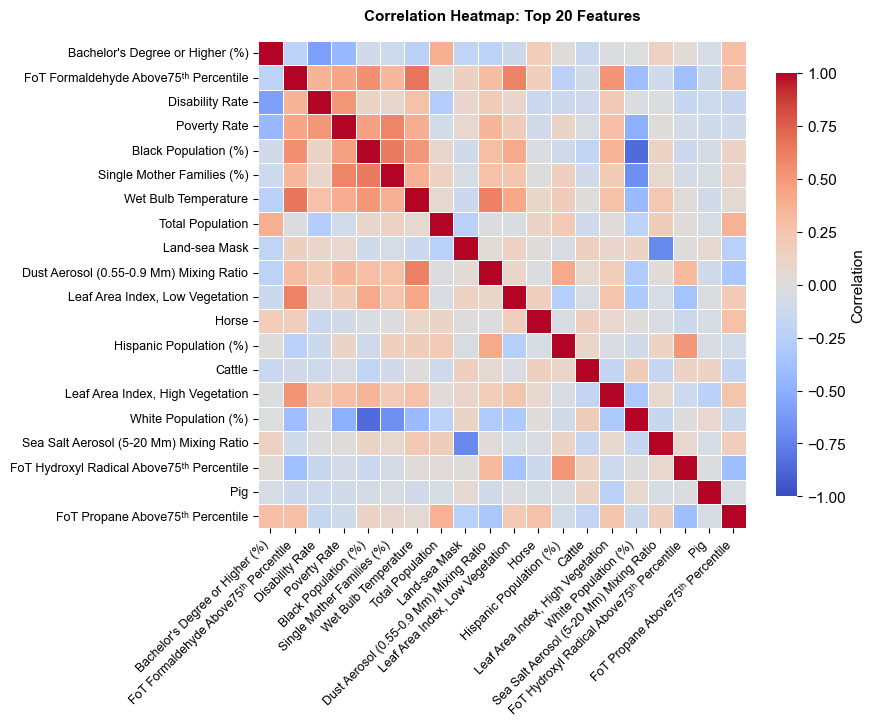

Figure 7A: Correlation heatmap for top 20 features.


In [98]:
corr_matrix_top20 = X_train_top20.corr()

fig, ax = plt.subplots(figsize=(DOUBLE_COL_WIDTH * 1.3, DOUBLE_COL_WIDTH * 1.1))
sns.heatmap(corr_matrix_top20, cmap='coolwarm', center=0, square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.8, "label": "Correlation"},
            vmin=-1, vmax=1, ax=ax)
ax.set_title('Correlation Heatmap: Top 20 Features',
             fontsize=FONT_SIZE, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig(f'{output_dir}fig7a_correlation_heatmap_top20.png', dpi=DPI, bbox_inches='tight')
plt.show()
print("Figure 7A: Correlation heatmap for top 20 features.")

### 6.3 Run Bayesian Optimization

In [99]:
bayes_top20 = BayesSearchCV(
    estimator=xgb.XGBRegressor(objective='reg:squarederror', random_state=42, tree_method='hist'),
    search_spaces=search_spaces,
    n_iter=30,
    cv=GroupKFold(n_splits=5),
    scoring="r2",
    n_jobs=-1,
    random_state=42,
    refit=True,
    verbose=1,
)

print("Starting Bayesian optimization for Top 20 features...")
print("Using GroupKFold to prevent county-level data leakage.")
print("This may take 10-15 minutes...\n")

bayes_top20.fit(X_train_top20, y_train, groups=groups_train)

print("\n" + "=" * 70)
print("OPTIMIZATION COMPLETE (TOP 20 FEATURES)")
print("=" * 70)
for param, value in bayes_top20.best_params_.items():
    print(f"  - {param}: {value}")
print(f"\nBest CV R²: {bayes_top20.best_score_:.4f}")

Starting Bayesian optimization for Top 20 features...
Using GroupKFold to prevent county-level data leakage.
This may take 10-15 minutes...

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 can

### 6.4 Generate Predictions and Calculate Metrics

In [100]:
best_model_top20 = bayes_top20.best_estimator_

train_predictions_top20 = best_model_top20.predict(X_train_top20)
test_predictions_top20  = best_model_top20.predict(X_test_top20)

train_rmse_top20 = np.sqrt(mean_squared_error(y_train, train_predictions_top20))
test_rmse_top20  = np.sqrt(mean_squared_error(y_test,  test_predictions_top20))
train_mae_top20  = mean_absolute_error(y_train, train_predictions_top20)
test_mae_top20   = mean_absolute_error(y_test,  test_predictions_top20)
r2_train_top20   = r2_score(y_train, train_predictions_top20)
r2_test_top20    = r2_score(y_test,  test_predictions_top20)

p_top20 = X_train_top20.shape[1]
adj_r2_train_top20 = 1 - (1 - r2_train_top20) * ((n_train - 1) / (n_train - p_top20 - 1))
adj_r2_test_top20  = 1 - (1 - r2_test_top20)  * ((n_test  - 1) / (n_test  - p_top20 - 1))

print("=" * 70)
print("MODEL PERFORMANCE METRICS (TOP 20 FEATURES)")
print("=" * 70)
print(f"\nTraining Set:")
print(f"  R² Score:       {r2_train_top20:.4f}")
print(f"  Adjusted R²:    {adj_r2_train_top20:.4f}")
print(f"  RMSE:           {train_rmse_top20:.2f} per 100,000")
print(f"  MAE:            {train_mae_top20:.2f} per 100,000")
print(f"\nTest Set:")
print(f"  R² Score:       {r2_test_top20:.4f}")
print(f"  Adjusted R²:    {adj_r2_test_top20:.4f}")
print(f"  RMSE:           {test_rmse_top20:.2f} per 100,000")
print(f"  MAE:            {test_mae_top20:.2f} per 100,000")

MODEL PERFORMANCE METRICS (TOP 20 FEATURES)

Training Set:
  R² Score:       0.9716
  Adjusted R²:    0.9716
  RMSE:           3.29 per 100,000
  MAE:            2.41 per 100,000

Test Set:
  R² Score:       0.7387
  Adjusted R²:    0.7377
  RMSE:           9.90 per 100,000
  MAE:            7.64 per 100,000


### 6.5 Save Metrics Table 2

In [101]:
metrics_summary_top20 = pd.DataFrame({
    'Metric': ['R² Score', 'Adjusted R²', 'RMSE (per 100,000)', 'MAE (per 100,000)', 'Sample Size'],
    'Training Set': [f'{r2_train_top20:.3f}', f'{adj_r2_train_top20:.3f}', f'{train_rmse_top20:.2f}', f'{train_mae_top20:.2f}', f'{len(y_train):,}'],
    'Test Set':     [f'{r2_test_top20:.3f}',  f'{adj_r2_test_top20:.3f}',  f'{test_rmse_top20:.2f}',  f'{test_mae_top20:.2f}',  f'{len(y_test):,}']
})
print("\nTable 2: Model Performance Metrics for Top 20 Features")
print("=" * 70)
display(metrics_summary_top20)
metrics_summary_top20.to_csv(f'{output_dir}table2_metrics_top20_features.csv', index=False)
print(f"\n Table saved to: {output_dir}table2_metrics_top20_features.csv")


Table 2: Model Performance Metrics for Top 20 Features


,Metric,Training Set,Test Set
0,R² Score,0.972,0.739
1,Adjusted R²,0.972,0.738
2,"RMSE (per 100,000)",3.29,9.90
3,"MAE (per 100,000)",2.41,7.64
4,Sample Size,"19,583","4,904"



 Table saved to: ../data/outputs/modeling/xgboost/table2_metrics_top20_features.csv


### 6.6 Figure 7B: Residual Analysis — Top 20 Features

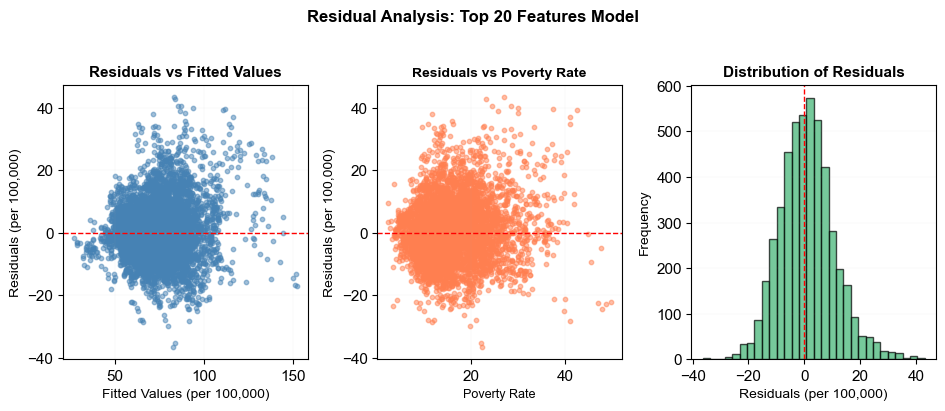

Figure 7B: Residual analysis for top 20 features model.


In [102]:
residuals_top20 = y_test - test_predictions_top20

fig, axes = plt.subplots(1, 3, figsize=(DOUBLE_COL_WIDTH * 1.4, 4))

axes[0].scatter(test_predictions_top20, residuals_top20, alpha=0.5, s=10, color='steelblue')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Fitted Values (per 100,000)', fontsize=FONT_SIZE - 1)
axes[0].set_ylabel('Residuals (per 100,000)', fontsize=FONT_SIZE - 1)
axes[0].set_title('Residuals vs Fitted Values', fontsize=FONT_SIZE, fontweight='bold')
axes[0].grid(axis='both', linewidth=0.15, alpha=0.3)

poverty_features = [f for f in top_20_features if 'Poverty' in f or 'poverty' in f.lower()]
if poverty_features:
    feat2 = poverty_features[0]
else:
    feat2 = top_20_features[0]
axes[1].scatter(X_test_top20[feat2], residuals_top20, alpha=0.5, s=10, color='coral')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel(feat2, fontsize=FONT_SIZE - 2)
axes[1].set_ylabel('Residuals (per 100,000)', fontsize=FONT_SIZE - 1)
axes[1].set_title(f'Residuals vs {feat2}', fontsize=FONT_SIZE - 1, fontweight='bold')
axes[1].grid(axis='both', linewidth=0.15, alpha=0.3)

axes[2].hist(residuals_top20, bins=30, color='mediumseagreen', alpha=0.7, edgecolor='black')
axes[2].axvline(x=0, color='red', linestyle='--', linewidth=1)
axes[2].set_xlabel('Residuals (per 100,000)', fontsize=FONT_SIZE - 1)
axes[2].set_ylabel('Frequency', fontsize=FONT_SIZE - 1)
axes[2].set_title('Distribution of Residuals', fontsize=FONT_SIZE, fontweight='bold')
axes[2].grid(axis='y', linewidth=0.15, alpha=0.3)

plt.suptitle('Residual Analysis: Top 20 Features Model',
             fontsize=FONT_SIZE + 1, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{output_dir}fig7b_residual_analysis_top20.png', dpi=DPI, bbox_inches='tight')
plt.show()
print("Figure 7B: Residual analysis for top 20 features model.")

### 6.7 Figure 8: Scatter Plot — Top 20 Features

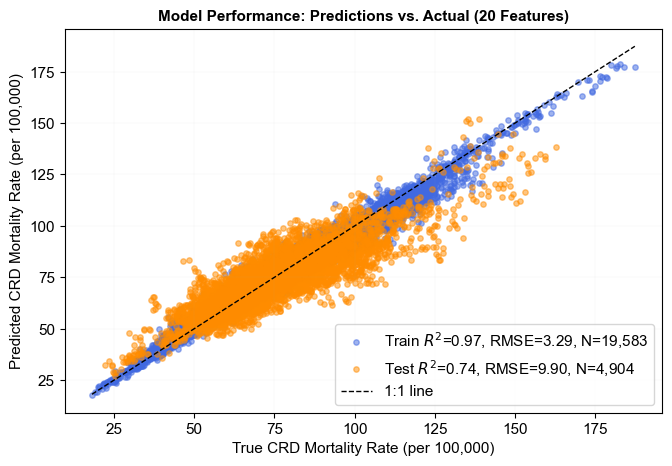

Figure 8: Scatter plot for top 20 features model.


In [103]:
fig, ax = plt.subplots(figsize=(DOUBLE_COL_WIDTH, DOUBLE_COL_WIDTH * 0.7))

ax.scatter(y_train, train_predictions_top20, color='royalblue',
           label=f'Train $R^2$={r2_train_top20:.2f}, RMSE={train_rmse_top20:.2f}, N={len(y_train):,}',
           alpha=0.5, s=15)
ax.scatter(y_test, test_predictions_top20, color='darkorange',
           label=f'Test $R^2$={r2_test_top20:.2f}, RMSE={test_rmse_top20:.2f}, N={len(y_test):,}',
           alpha=0.5, s=15)
ax.plot([y.min(), y.max()], [y.min(), y.max()],
        linestyle='--', color='black', linewidth=1, label='1:1 line')

ax.set_xlabel('True CRD Mortality Rate (per 100,000)', fontsize=FONT_SIZE)
ax.set_ylabel('Predicted CRD Mortality Rate (per 100,000)', fontsize=FONT_SIZE)
ax.set_title('Model Performance: Predictions vs. Actual (20 Features)',
             fontsize=FONT_SIZE, fontweight='bold')
ax.legend(fontsize=11, frameon=True, loc='lower right')
ax.grid(axis='both', linewidth=0.15, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{output_dir}fig8_scatter_performance_top20.png', dpi=DPI, bbox_inches='tight')
plt.show()
print("Figure 8: Scatter plot for top 20 features model.")

### 6.8 Figure 9: Q-Q Plot — Top 20 Features

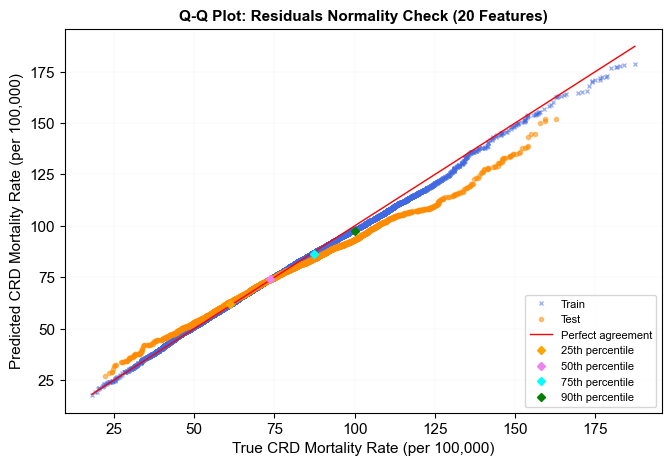

Figure 9: Q-Q plot for top 20 features model.


In [104]:
train_preds_sorted_top20  = np.sort(train_predictions_top20)
test_preds_sorted_top20   = np.sort(test_predictions_top20)
all_predictions_top20     = np.concatenate((train_predictions_top20, test_predictions_top20))

fig, ax = plt.subplots(figsize=(DOUBLE_COL_WIDTH, DOUBLE_COL_WIDTH * 0.7))

ax.plot(np.sort(y_train), train_preds_sorted_top20, 'x',
        label='Train', alpha=0.5, color='royalblue', markersize=3)
ax.plot(np.sort(y_test), test_preds_sorted_top20, 'o',
        label='Test', alpha=0.5, color='darkorange', markersize=3)
ax.plot([all_targets.min(), all_targets.max()], [all_targets.min(), all_targets.max()],
        'r', linewidth=1, label='Perfect agreement')

for percentile, color, label in [(25, 'orange', '25th'), (50, 'violet', '50th'),
                                   (75, 'cyan', '75th'), (90, 'green', '90th')]:
    target_pct = np.percentile(np.sort(all_targets), percentile)
    pred_pct   = np.percentile(np.sort(all_predictions_top20), percentile)
    ax.plot(target_pct, pred_pct, marker="D", markersize=4,
            color=color, linestyle='None', label=f"{label} percentile")

ax.set_title('Q-Q Plot: Residuals Normality Check (20 Features)',
             fontsize=FONT_SIZE, fontweight="bold")
ax.set_xlabel('True CRD Mortality Rate (per 100,000)', fontsize=FONT_SIZE)
ax.set_ylabel('Predicted CRD Mortality Rate (per 100,000)', fontsize=FONT_SIZE)
ax.grid(axis='both', linewidth=0.15, alpha=0.3)
ax.legend(fontsize=8, frameon=True, loc='lower right')

plt.tight_layout()
plt.savefig(f'{output_dir}fig9_qq_plot_top20.png', dpi=DPI, bbox_inches='tight')
plt.show()
print("Figure 9: Q-Q plot for top 20 features model.")

### 6.9 Calculate Permutation Importance

In [105]:
print("Calculating permutation importance for top 20 features...")
perm_importance_top20 = permutation_importance(best_model_top20, X_test_top20, y_test,
                                                n_repeats=10, random_state=42)
perm_importance_df_top20 = pd.DataFrame({
    'Feature':    X_test_top20.columns,
    'Importance': perm_importance_top20.importances_mean
}).sort_values(by='Importance', ascending=False)
print(f" Permutation importance calculated")

Calculating permutation importance for top 20 features...
 Permutation importance calculated


### 6.10 Figure 10: Permutation Importance — Top 20 Features

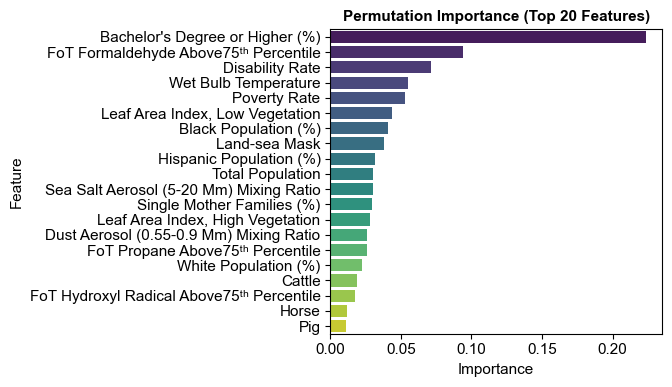

Figure 10: Permutation importance for top 20 features model.


In [106]:
fig, ax = plt.subplots(figsize=(DOUBLE_COL_WIDTH, 4))
sns.barplot(x='Importance', y='Feature', data=perm_importance_df_top20,
            palette='viridis', ax=ax)
ax.set_title('Permutation Importance (Top 20 Features)',
             fontsize=FONT_SIZE, fontweight='bold')
ax.set_xlabel('Importance', fontsize=FONT_SIZE)
ax.set_ylabel('Feature', fontsize=FONT_SIZE)
plt.tight_layout()
plt.savefig(f'{output_dir}fig10_permutation_importance_top20.png', dpi=DPI, bbox_inches='tight')
plt.show()
print("Figure 10: Permutation importance for top 20 features model.")

### 6.11 Compute SHAP Values

In [107]:
print("Computing SHAP values for top 20 features...")
explainer_top20   = shap.TreeExplainer(best_model_top20)
shap_values_top20 = explainer_top20.shap_values(X_test_top20)
print(f" SHAP values computed")

Computing SHAP values for top 20 features...
 SHAP values computed


### 6.12 Figure 11: SHAP Summary Plot — Top 20 Features

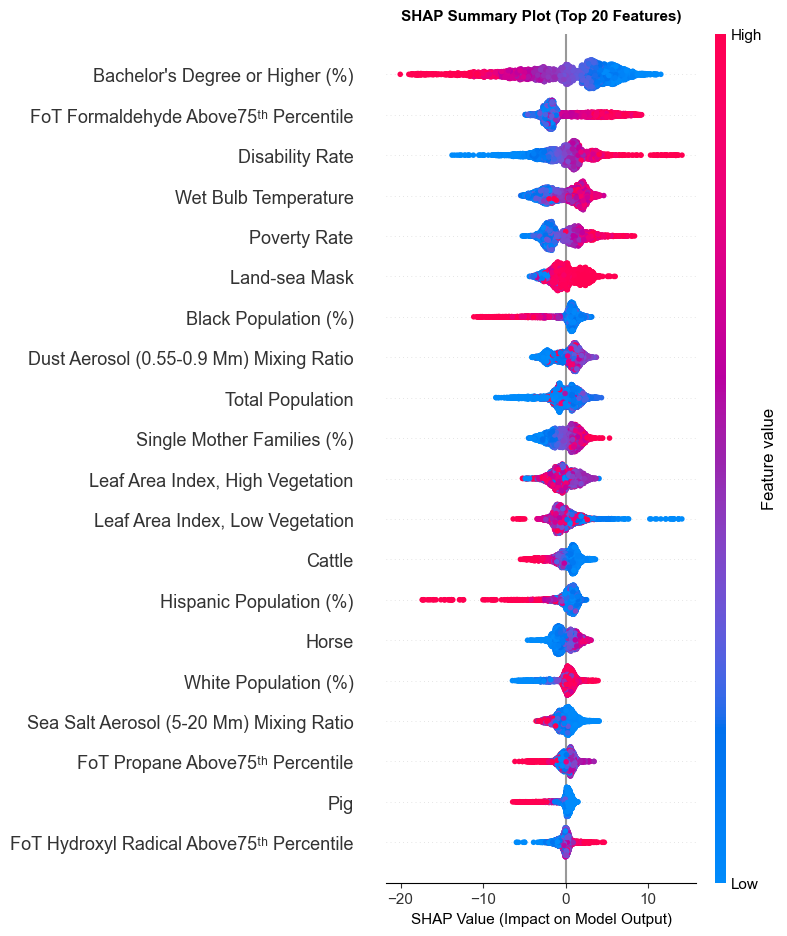

Figure 11: SHAP summary plot for top 20 features model.


In [108]:
plt.figure(figsize=(DOUBLE_COL_WIDTH, 5))
shap.summary_plot(shap_values_top20, X_test_top20, max_display=20, show=False)
plt.title('SHAP Summary Plot (Top 20 Features)',
          fontsize=FONT_SIZE, fontweight='bold', pad=10)
plt.xlabel('SHAP Value (Impact on Model Output)', fontsize=FONT_SIZE)
plt.tight_layout()
plt.savefig(f'{output_dir}fig11_shap_summary_top20.png', dpi=DPI, bbox_inches='tight')
plt.show()
print("Figure 11: SHAP summary plot for top 20 features model.")

### 6.13 Figure 12: SHAP Bar Plot — Top 20 Features

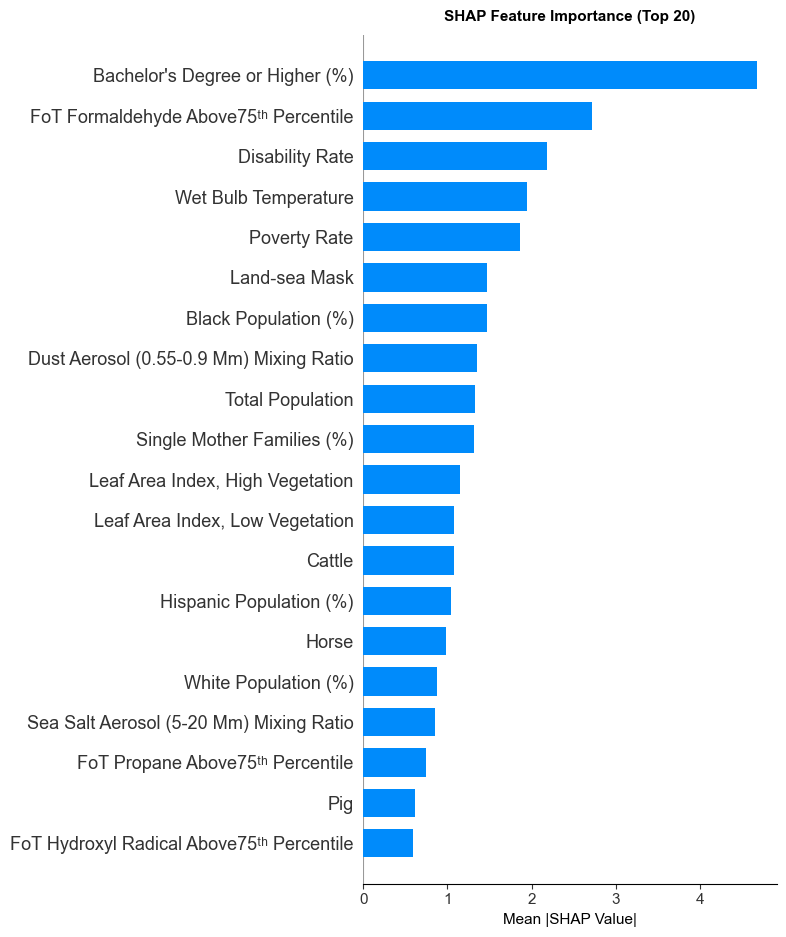

Figure 12: SHAP bar plot for top 20 features model.


In [109]:
plt.figure(figsize=(SINGLE_COL_WIDTH, 4))
shap.summary_plot(shap_values_top20, X_test_top20, plot_type="bar", max_display=20, show=False)
plt.title('SHAP Feature Importance (Top 20)',
          fontsize=FONT_SIZE, fontweight='bold', pad=10)
plt.xlabel('Mean |SHAP Value|', fontsize=FONT_SIZE)
plt.tight_layout()
plt.savefig(f'{output_dir}fig12_shap_bar_top20.png', dpi=DPI, bbox_inches='tight')
plt.show()
print("Figure 12: SHAP bar plot for top 20 features model.")

### 6.14 Identify Top 3 Features by SHAP

In [110]:
shap_importance_top20 = np.abs(shap_values_top20).mean(axis=0)
top_3_indices_top20  = np.argsort(shap_importance_top20)[-3:][::-1]
top_3_features_top20 = [X_test_top20.columns[i] for i in top_3_indices_top20]
print(f"Top 3 features for dependence plots: {top_3_features_top20}")

Top 3 features for dependence plots: ["Bachelor's Degree or Higher (%)", 'FoT Formaldehyde Above75ᵗʰ Percentile', 'Disability Rate']


### 6.15 Figure 13: SHAP Dependence Plots — Top 20 Features

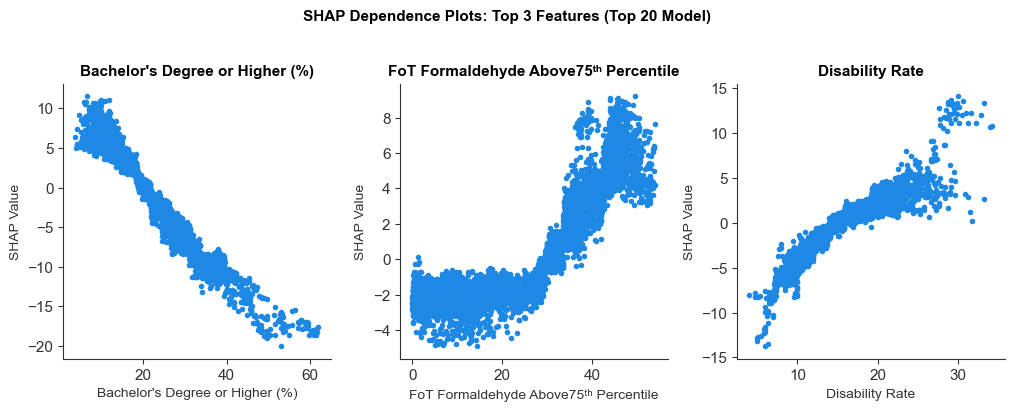

Figure 13: SHAP dependence plots for top 20 features model.


In [111]:
fig, axes = plt.subplots(1, 3, figsize=(DOUBLE_COL_WIDTH * 1.5, 4))

for idx, feature in enumerate(top_3_features_top20):
    shap.dependence_plot(feature, shap_values_top20, X_test_top20,
                         ax=axes[idx], show=False, interaction_index=None)
    axes[idx].set_title(f'{feature}', fontsize=FONT_SIZE, fontweight='bold')
    axes[idx].set_xlabel(feature, fontsize=FONT_SIZE - 1)
    axes[idx].set_ylabel('SHAP Value', fontsize=FONT_SIZE - 1)

plt.suptitle('SHAP Dependence Plots: Top 3 Features (Top 20 Model)',
             fontsize=FONT_SIZE, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{output_dir}fig13_shap_dependence_top20.png', dpi=DPI, bbox_inches='tight')
plt.show()
print("Figure 13: SHAP dependence plots for top 20 features model.")

### 6.16 5-Fold Cross-Validation (GroupKFold)

In [112]:
print("Performing cross-validation for top 20 features...")
gkf = GroupKFold(n_splits=5)
cv_scores_r2_top20   = cross_val_score(best_model_top20, X, y, groups=groups,
                                        cv=gkf, scoring='r2', n_jobs=-1)
cv_scores_rmse_top20 = -cross_val_score(best_model_top20, X, y, groups=groups,
                                         cv=gkf, scoring='neg_root_mean_squared_error', n_jobs=-1)
print(f" Cross-validation complete")
print(f"  R² scores: {cv_scores_r2_top20}")
print(f"  Mean R²: {cv_scores_r2_top20.mean():.4f} (+/- {cv_scores_r2_top20.std():.4f})")
print(f"  Mean RMSE: {cv_scores_rmse_top20.mean():.2f} (+/- {cv_scores_rmse_top20.std():.2f})")

Performing cross-validation for top 20 features...
 Cross-validation complete
  R² scores: [0.76907955 0.76596964 0.74203852 0.75032779 0.74091975]
  Mean R²: 0.7537 (+/- 0.0118)
  Mean RMSE: 9.67 (+/- 0.18)


### 6.17 Figure 14: Cross-Validation Boxplots

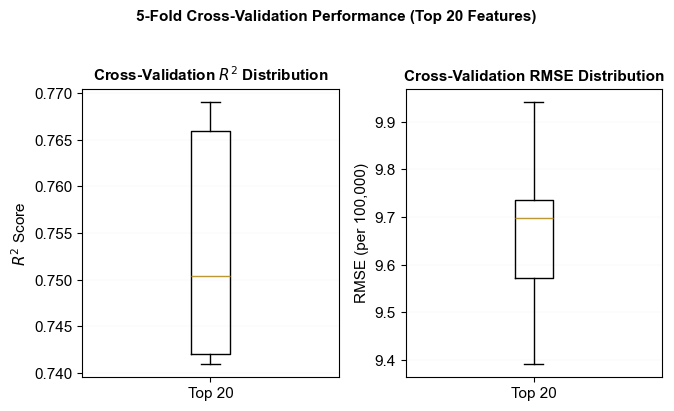

Figure 14: Cross-validation performance for top 20 features model.


In [113]:
fig, axes = plt.subplots(1, 2, figsize=(DOUBLE_COL_WIDTH, 4))

axes[0].boxplot([cv_scores_r2_top20], labels=['Top 20'])
axes[0].set_ylabel('$R^2$ Score', fontsize=FONT_SIZE)
axes[0].set_title('Cross-Validation $R^2$ Distribution', fontsize=FONT_SIZE, fontweight='bold')
axes[0].grid(axis='y', linewidth=0.15, alpha=0.3)

axes[1].boxplot([cv_scores_rmse_top20], labels=['Top 20'])
axes[1].set_ylabel('RMSE (per 100,000)', fontsize=FONT_SIZE)
axes[1].set_title('Cross-Validation RMSE Distribution', fontsize=FONT_SIZE, fontweight='bold')
axes[1].grid(axis='y', linewidth=0.15, alpha=0.3)

plt.suptitle('5-Fold Cross-Validation Performance (Top 20 Features)',
             fontsize=FONT_SIZE, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{output_dir}fig14_cross_validation_top20.png', dpi=DPI, bbox_inches='tight')
plt.show()
print("Figure 14: Cross-validation performance for top 20 features model.")

## 7. Top 10 Features Model

### 7.1 Extract Top 10 Features by SHAP Importance

In [114]:
top_10_indices  = np.argsort(shap_importance_top20)[-10:][::-1]
top_10_features = [X_test_top20.columns[i] for i in top_10_indices]

X_train_top10 = X_train[top_10_features]
X_test_top10  = X_test[top_10_features]

print("=" * 70)
print("TOP 10 FEATURES (by SHAP importance from Top 20)")
print("=" * 70)
for i, feat in enumerate(top_10_features, 1):
    print(f"  {i:2}. {feat}")
print(f"\n Training set shape: {X_train_top10.shape}")
print(f"  Test set shape: {X_test_top10.shape}")

TOP 10 FEATURES (by SHAP importance from Top 20)
   1. Bachelor's Degree or Higher (%)
   2. FoT Formaldehyde Above75ᵗʰ Percentile
   3. Disability Rate
   4. Wet Bulb Temperature
   5. Poverty Rate
   6. Land-sea Mask
   7. Black Population (%)
   8. Dust Aerosol (0.55-0.9 Μm) Mixing Ratio
   9. Total Population
  10. Single Mother Families (%)

 Training set shape: (19583, 10)
  Test set shape: (4904, 10)


### 7.2 Figure 15A: Correlation Heatmap — Top 10 Features (Annotated)

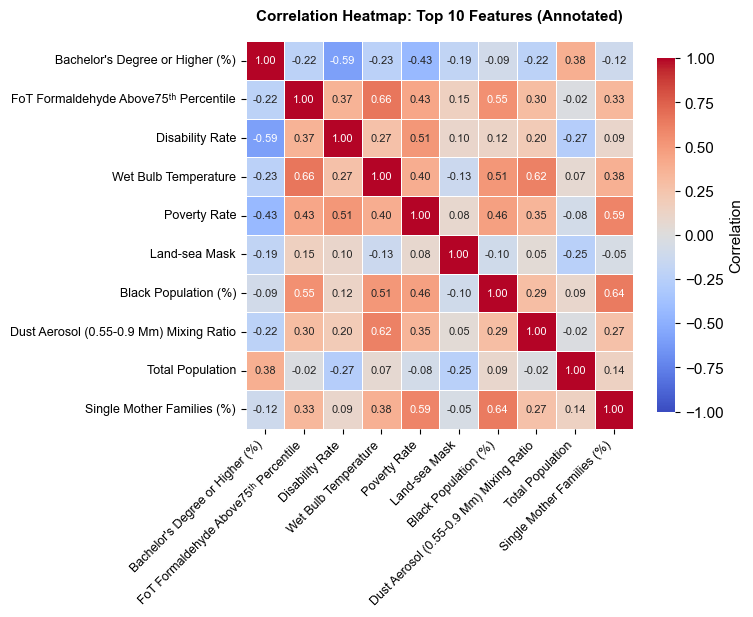

Figure 15A: Annotated correlation heatmap for top 10 features.


In [115]:
corr_matrix_top10 = X_train_top10.corr()

fig, ax = plt.subplots(figsize=(DOUBLE_COL_WIDTH * 1.1, DOUBLE_COL_WIDTH * 0.95))
sns.heatmap(corr_matrix_top10, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8, "label": "Correlation"},
            vmin=-1, vmax=1, ax=ax, annot_kws={"size": 8})
ax.set_title('Correlation Heatmap: Top 10 Features (Annotated)',
             fontsize=FONT_SIZE, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig(f'{output_dir}fig15a_correlation_heatmap_top10.png', dpi=DPI, bbox_inches='tight')
plt.show()
print("Figure 15A: Annotated correlation heatmap for top 10 features.")

### 7.3 Run Bayesian Optimization

In [116]:
bayes_top10 = BayesSearchCV(
    estimator=xgb.XGBRegressor(objective='reg:squarederror', random_state=42, tree_method='hist'),
    search_spaces=search_spaces,
    n_iter=30,
    cv=GroupKFold(n_splits=5),
    scoring="r2",
    n_jobs=-1,
    random_state=42,
    refit=True,
    verbose=1,
)

print("Starting Bayesian optimization for Top 10 features...")
bayes_top10.fit(X_train_top10, y_train, groups=groups_train)

print("\n" + "=" * 70)
print("OPTIMIZATION COMPLETE (TOP 10 FEATURES)")
print("=" * 70)
for param, value in bayes_top10.best_params_.items():
    print(f"  - {param}: {value}")
print(f"\nBest CV R²: {bayes_top10.best_score_:.4f}")

Starting Bayesian optimization for Top 10 features...
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fi

### 7.4 Generate Predictions and Calculate Metrics

In [117]:
best_model_top10 = bayes_top10.best_estimator_

train_predictions_top10 = best_model_top10.predict(X_train_top10)
test_predictions_top10  = best_model_top10.predict(X_test_top10)

train_rmse_top10 = np.sqrt(mean_squared_error(y_train, train_predictions_top10))
test_rmse_top10  = np.sqrt(mean_squared_error(y_test,  test_predictions_top10))
train_mae_top10  = mean_absolute_error(y_train, train_predictions_top10)
test_mae_top10   = mean_absolute_error(y_test,  test_predictions_top10)
r2_train_top10   = r2_score(y_train, train_predictions_top10)
r2_test_top10    = r2_score(y_test,  test_predictions_top10)

p_top10 = X_train_top10.shape[1]
adj_r2_train_top10 = 1 - (1 - r2_train_top10) * ((n_train - 1) / (n_train - p_top10 - 1))
adj_r2_test_top10  = 1 - (1 - r2_test_top10)  * ((n_test  - 1) / (n_test  - p_top10 - 1))

print("=" * 70)
print("MODEL PERFORMANCE METRICS (TOP 10 FEATURES)")
print("=" * 70)
print(f"\nTraining Set:")
print(f"  R² Score:       {r2_train_top10:.4f}")
print(f"  Adjusted R²:    {adj_r2_train_top10:.4f}")
print(f"  RMSE:           {train_rmse_top10:.2f} per 100,000")
print(f"  MAE:            {train_mae_top10:.2f} per 100,000")
print(f"\nTest Set:")
print(f"  R² Score:       {r2_test_top10:.4f}")
print(f"  Adjusted R²:    {adj_r2_test_top10:.4f}")
print(f"  RMSE:           {test_rmse_top10:.2f} per 100,000")
print(f"  MAE:            {test_mae_top10:.2f} per 100,000")

MODEL PERFORMANCE METRICS (TOP 10 FEATURES)

Training Set:
  R² Score:       0.8793
  Adjusted R²:    0.8792
  RMSE:           6.78 per 100,000
  MAE:            5.17 per 100,000

Test Set:
  R² Score:       0.6996
  Adjusted R²:    0.6990
  RMSE:           10.61 per 100,000
  MAE:            8.16 per 100,000


### 7.5 Save Metrics Table 3

In [118]:
metrics_summary_top10 = pd.DataFrame({
    'Metric': ['R² Score', 'Adjusted R²', 'RMSE (per 100,000)', 'MAE (per 100,000)', 'Sample Size'],
    'Training Set': [f'{r2_train_top10:.3f}', f'{adj_r2_train_top10:.3f}', f'{train_rmse_top10:.2f}', f'{train_mae_top10:.2f}', f'{len(y_train):,}'],
    'Test Set':     [f'{r2_test_top10:.3f}',  f'{adj_r2_test_top10:.3f}',  f'{test_rmse_top10:.2f}',  f'{test_mae_top10:.2f}',  f'{len(y_test):,}']
})
print("\nTable 3: Model Performance Metrics for Top 10 Features")
print("=" * 70)
display(metrics_summary_top10)
metrics_summary_top10.to_csv(f'{output_dir}table3_metrics_top10_features.csv', index=False)
print(f"\n Table saved to: {output_dir}table3_metrics_top10_features.csv")


Table 3: Model Performance Metrics for Top 10 Features


,Metric,Training Set,Test Set
0,R² Score,0.879,0.700
1,Adjusted R²,0.879,0.699
2,"RMSE (per 100,000)",6.78,10.61
3,"MAE (per 100,000)",5.17,8.16
4,Sample Size,"19,583","4,904"



 Table saved to: ../data/outputs/modeling/xgboost/table3_metrics_top10_features.csv


### 7.6 Figure 15B: Scatter Plot — Top 10 Features

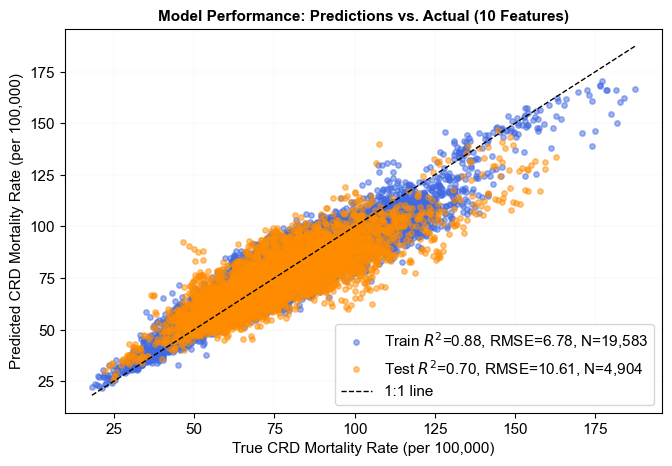

Figure 15B: Scatter plot for top 10 features model.


In [119]:
fig, ax = plt.subplots(figsize=(DOUBLE_COL_WIDTH, DOUBLE_COL_WIDTH * 0.7))

ax.scatter(y_train, train_predictions_top10, color='royalblue',
           label=f'Train $R^2$={r2_train_top10:.2f}, RMSE={train_rmse_top10:.2f}, N={len(y_train):,}',
           alpha=0.5, s=15)
ax.scatter(y_test, test_predictions_top10, color='darkorange',
           label=f'Test $R^2$={r2_test_top10:.2f}, RMSE={test_rmse_top10:.2f}, N={len(y_test):,}',
           alpha=0.5, s=15)
ax.plot([y.min(), y.max()], [y.min(), y.max()],
        linestyle='--', color='black', linewidth=1, label='1:1 line')

ax.set_xlabel('True CRD Mortality Rate (per 100,000)', fontsize=FONT_SIZE)
ax.set_ylabel('Predicted CRD Mortality Rate (per 100,000)', fontsize=FONT_SIZE)
ax.set_title('Model Performance: Predictions vs. Actual (10 Features)',
             fontsize=FONT_SIZE, fontweight='bold')
ax.legend(fontsize=11, frameon=True, loc='lower right')
ax.grid(axis='both', linewidth=0.15, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{output_dir}fig15b_scatter_performance_top10.png', dpi=DPI, bbox_inches='tight')
plt.show()
print("Figure 15B: Scatter plot for top 10 features model.")

### 7.7 Figure 16: Q-Q Plot — Top 10 Features

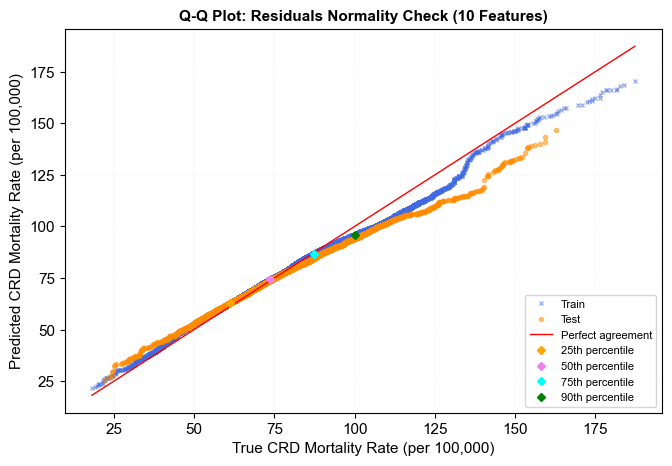

Figure 16: Q-Q plot for top 10 features model.


In [120]:
all_predictions_top10 = np.concatenate((train_predictions_top10, test_predictions_top10))

fig, ax = plt.subplots(figsize=(DOUBLE_COL_WIDTH, DOUBLE_COL_WIDTH * 0.7))

ax.plot(np.sort(y_train), np.sort(train_predictions_top10), 'x',
        label='Train', alpha=0.5, color='royalblue', markersize=3)
ax.plot(np.sort(y_test), np.sort(test_predictions_top10), 'o',
        label='Test', alpha=0.5, color='darkorange', markersize=3)
ax.plot([all_targets.min(), all_targets.max()], [all_targets.min(), all_targets.max()],
        'r', linewidth=1, label='Perfect agreement')

for percentile, color, label in [(25, 'orange', '25th'), (50, 'violet', '50th'),
                                   (75, 'cyan', '75th'), (90, 'green', '90th')]:
    target_pct = np.percentile(np.sort(all_targets), percentile)
    pred_pct   = np.percentile(np.sort(all_predictions_top10), percentile)
    ax.plot(target_pct, pred_pct, marker="D", markersize=4,
            color=color, linestyle='None', label=f"{label} percentile")

ax.set_title('Q-Q Plot: Residuals Normality Check (10 Features)',
             fontsize=FONT_SIZE, fontweight="bold")
ax.set_xlabel('True CRD Mortality Rate (per 100,000)', fontsize=FONT_SIZE)
ax.set_ylabel('Predicted CRD Mortality Rate (per 100,000)', fontsize=FONT_SIZE)
ax.grid(axis='both', linewidth=0.15, alpha=0.3)
ax.legend(fontsize=8, frameon=True, loc='lower right')

plt.tight_layout()
plt.savefig(f'{output_dir}fig16_qq_plot_top10.png', dpi=DPI, bbox_inches='tight')
plt.show()
print("Figure 16: Q-Q plot for top 10 features model.")

### 7.8 Calculate Permutation Importance

In [121]:
print("Calculating permutation importance for top 10 features...")
perm_importance_top10 = permutation_importance(best_model_top10, X_test_top10, y_test,
                                                n_repeats=10, random_state=42)
perm_importance_df_top10 = pd.DataFrame({
    'Feature':    X_test_top10.columns,
    'Importance': perm_importance_top10.importances_mean
}).sort_values(by='Importance', ascending=False)
print(f" Permutation importance calculated")

Calculating permutation importance for top 10 features...
 Permutation importance calculated


### 7.9 Figure 17: Permutation Importance — Top 10 Features

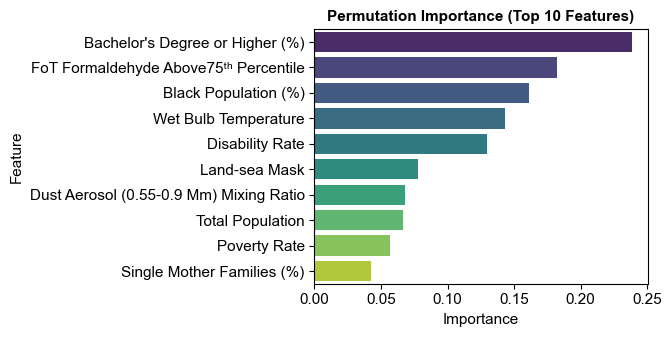

Figure 17: Permutation importance for top 10 features model.


In [122]:
fig, ax = plt.subplots(figsize=(DOUBLE_COL_WIDTH, 3.5))
sns.barplot(x='Importance', y='Feature', data=perm_importance_df_top10,
            palette='viridis', ax=ax)
ax.set_title('Permutation Importance (Top 10 Features)',
             fontsize=FONT_SIZE, fontweight='bold')
ax.set_xlabel('Importance', fontsize=FONT_SIZE)
ax.set_ylabel('Feature', fontsize=FONT_SIZE)
plt.tight_layout()
plt.savefig(f'{output_dir}fig17_permutation_importance_top10.png', dpi=DPI, bbox_inches='tight')
plt.show()
print("Figure 17: Permutation importance for top 10 features model.")

### 7.10 Compute SHAP Values

In [123]:
print("Computing SHAP values for top 10 features...")
explainer_top10   = shap.TreeExplainer(best_model_top10)
shap_values_top10 = explainer_top10.shap_values(X_test_top10)
print(f" SHAP values computed")

Computing SHAP values for top 10 features...
 SHAP values computed


### 7.11 Figure 18: SHAP Summary Plot — Top 10 Features

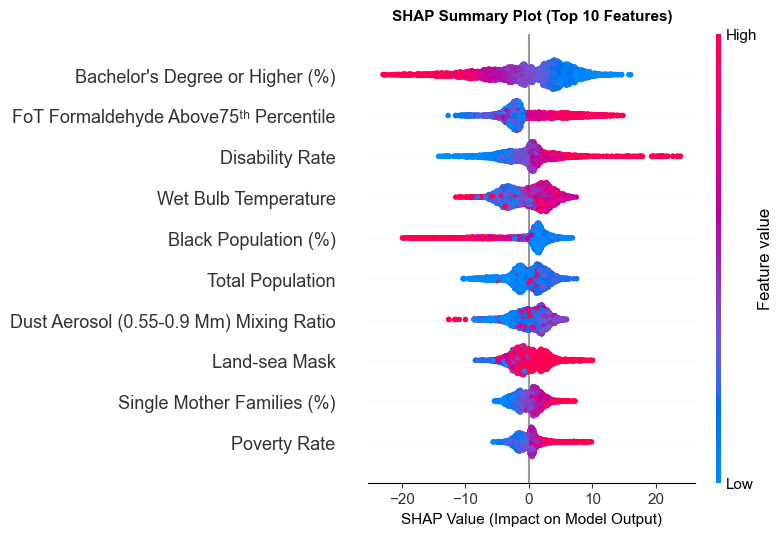

Figure 18: SHAP summary plot for top 10 features model.


In [124]:
plt.figure(figsize=(DOUBLE_COL_WIDTH, 4))
shap.summary_plot(shap_values_top10, X_test_top10, max_display=10, show=False)
plt.title('SHAP Summary Plot (Top 10 Features)',
          fontsize=FONT_SIZE, fontweight='bold', pad=10)
plt.xlabel('SHAP Value (Impact on Model Output)', fontsize=FONT_SIZE)
plt.tight_layout()
plt.savefig(f'{output_dir}fig18_shap_summary_top10.png', dpi=DPI, bbox_inches='tight')
plt.show()
print("Figure 18: SHAP summary plot for top 10 features model.")

### 7.12 Figure 19: SHAP Bar Plot — Top 10 Features

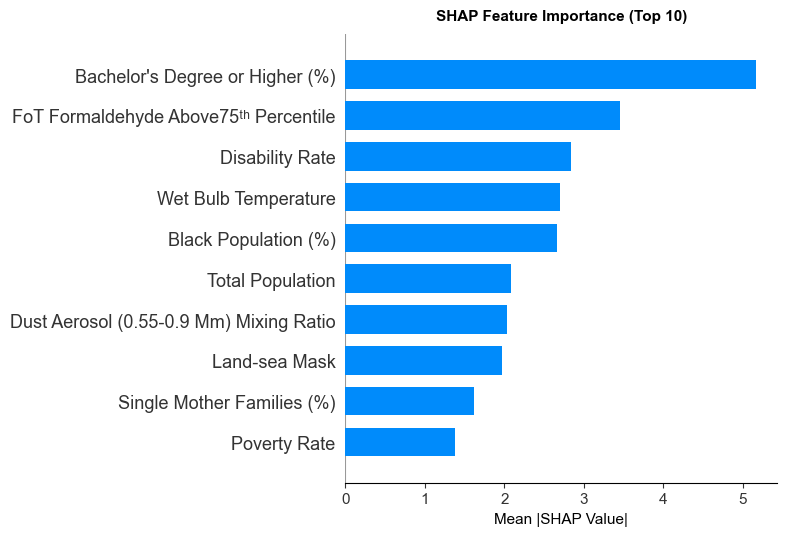

Figure 19: SHAP bar plot for top 10 features model.


In [125]:
plt.figure(figsize=(SINGLE_COL_WIDTH, 3.5))
shap.summary_plot(shap_values_top10, X_test_top10, plot_type="bar", max_display=10, show=False)
plt.title('SHAP Feature Importance (Top 10)',
          fontsize=FONT_SIZE, fontweight='bold', pad=10)
plt.xlabel('Mean |SHAP Value|', fontsize=FONT_SIZE)
plt.tight_layout()
plt.savefig(f'{output_dir}fig19_shap_bar_top10.png', dpi=DPI, bbox_inches='tight')
plt.show()
print("Figure 19: SHAP bar plot for top 10 features model.")

### 7.13 Identify Top 3 Features by SHAP

In [126]:
shap_importance_top10 = np.abs(shap_values_top10).mean(axis=0)
top_3_indices_top10  = np.argsort(shap_importance_top10)[-3:][::-1]
top_3_features_top10 = [X_test_top10.columns[i] for i in top_3_indices_top10]
print(f"Top 3 features for dependence plots: {top_3_features_top10}")

Top 3 features for dependence plots: ["Bachelor's Degree or Higher (%)", 'FoT Formaldehyde Above75ᵗʰ Percentile', 'Disability Rate']


### 7.14 Figure 20: SHAP Dependence Plots — Top 10 Features

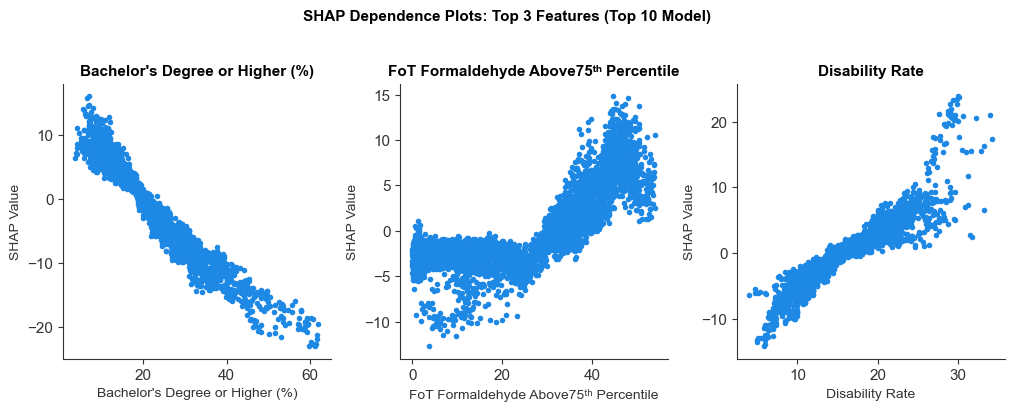

Figure 20: SHAP dependence plots for top 10 features model.


In [127]:
fig, axes = plt.subplots(1, 3, figsize=(DOUBLE_COL_WIDTH * 1.5, 4))

for idx, feature in enumerate(top_3_features_top10):
    shap.dependence_plot(feature, shap_values_top10, X_test_top10,
                         ax=axes[idx], show=False, interaction_index=None)
    axes[idx].set_title(f'{feature}', fontsize=FONT_SIZE, fontweight='bold')
    axes[idx].set_xlabel(feature, fontsize=FONT_SIZE - 1)
    axes[idx].set_ylabel('SHAP Value', fontsize=FONT_SIZE - 1)

plt.suptitle('SHAP Dependence Plots: Top 3 Features (Top 10 Model)',
             fontsize=FONT_SIZE, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{output_dir}fig20_shap_dependence_top10.png', dpi=DPI, bbox_inches='tight')
plt.show()
print("Figure 20: SHAP dependence plots for top 10 features model.")

## 8. Top 5 Features Model

### 8.1 Extract Top 5 Features by SHAP Importance

In [128]:
top_5_indices  = np.argsort(shap_importance_top10)[-5:][::-1]
top_5_features = [X_test_top10.columns[i] for i in top_5_indices]

X_train_top5 = X_train[top_5_features]
X_test_top5  = X_test[top_5_features]

print("=" * 70)
print("TOP 5 FEATURES (by SHAP importance from Top 10)")
print("=" * 70)
for i, feat in enumerate(top_5_features, 1):
    print(f"  {i}. {feat}")
print(f"\n Training set shape: {X_train_top5.shape}")
print(f"  Test set shape: {X_test_top5.shape}")

TOP 5 FEATURES (by SHAP importance from Top 10)
  1. Bachelor's Degree or Higher (%)
  2. FoT Formaldehyde Above75ᵗʰ Percentile
  3. Disability Rate
  4. Wet Bulb Temperature
  5. Black Population (%)

 Training set shape: (19583, 5)
  Test set shape: (4904, 5)


### 8.2 Run Bayesian Optimization

In [129]:
bayes_top5 = BayesSearchCV(
    estimator=xgb.XGBRegressor(objective='reg:squarederror', random_state=42, tree_method='hist'),
    search_spaces=search_spaces,
    n_iter=30,
    cv=GroupKFold(n_splits=5),
    scoring="r2",
    n_jobs=-1,
    random_state=42,
    refit=True,
    verbose=1,
)

print("Starting Bayesian optimization for Top 5 features...")
bayes_top5.fit(X_train_top5, y_train, groups=groups_train)

print("\n" + "=" * 70)
print("OPTIMIZATION COMPLETE (TOP 5 FEATURES)")
print("=" * 70)
for param, value in bayes_top5.best_params_.items():
    print(f"  - {param}: {value}")
print(f"\nBest CV R²: {bayes_top5.best_score_:.4f}")

Starting Bayesian optimization for Top 5 features...
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fit

### 8.3 Generate Predictions and Calculate Metrics

In [130]:
best_model_top5 = bayes_top5.best_estimator_

train_predictions_top5 = best_model_top5.predict(X_train_top5)
test_predictions_top5  = best_model_top5.predict(X_test_top5)

train_rmse_top5 = np.sqrt(mean_squared_error(y_train, train_predictions_top5))
test_rmse_top5  = np.sqrt(mean_squared_error(y_test,  test_predictions_top5))
train_mae_top5  = mean_absolute_error(y_train, train_predictions_top5)
test_mae_top5   = mean_absolute_error(y_test,  test_predictions_top5)
r2_train_top5   = r2_score(y_train, train_predictions_top5)
r2_test_top5    = r2_score(y_test,  test_predictions_top5)

p_top5 = X_train_top5.shape[1]
adj_r2_train_top5 = 1 - (1 - r2_train_top5) * ((n_train - 1) / (n_train - p_top5 - 1))
adj_r2_test_top5  = 1 - (1 - r2_test_top5)  * ((n_test  - 1) / (n_test  - p_top5 - 1))

print("=" * 70)
print("MODEL PERFORMANCE METRICS (TOP 5 FEATURES)")
print("=" * 70)
print(f"\nTraining Set:")
print(f"  R² Score:       {r2_train_top5:.4f}")
print(f"  Adjusted R²:    {adj_r2_train_top5:.4f}")
print(f"  RMSE:           {train_rmse_top5:.2f} per 100,000")
print(f"  MAE:            {train_mae_top5:.2f} per 100,000")
print(f"\nTest Set:")
print(f"  R² Score:       {r2_test_top5:.4f}")
print(f"  Adjusted R²:    {adj_r2_test_top5:.4f}")
print(f"  RMSE:           {test_rmse_top5:.2f} per 100,000")
print(f"  MAE:            {test_mae_top5:.2f} per 100,000")

MODEL PERFORMANCE METRICS (TOP 5 FEATURES)

Training Set:
  R² Score:       0.6937
  Adjusted R²:    0.6936
  RMSE:           10.81 per 100,000
  MAE:            8.31 per 100,000

Test Set:
  R² Score:       0.5835
  Adjusted R²:    0.5831
  RMSE:           12.49 per 100,000
  MAE:            9.76 per 100,000


### 8.4 Save Metrics Table 4

In [131]:
metrics_summary_top5 = pd.DataFrame({
    'Metric': ['R² Score', 'Adjusted R²', 'RMSE (per 100,000)', 'MAE (per 100,000)', 'Sample Size'],
    'Training Set': [f'{r2_train_top5:.3f}', f'{adj_r2_train_top5:.3f}', f'{train_rmse_top5:.2f}', f'{train_mae_top5:.2f}', f'{len(y_train):,}'],
    'Test Set':     [f'{r2_test_top5:.3f}',  f'{adj_r2_test_top5:.3f}',  f'{test_rmse_top5:.2f}',  f'{test_mae_top5:.2f}',  f'{len(y_test):,}']
})
print("\nTable 4: Model Performance Metrics for Top 5 Features")
print("=" * 70)
display(metrics_summary_top5)
metrics_summary_top5.to_csv(f'{output_dir}table4_metrics_top5_features.csv', index=False)
print(f"\n Table saved to: {output_dir}table4_metrics_top5_features.csv")


Table 4: Model Performance Metrics for Top 5 Features


,Metric,Training Set,Test Set
0,R² Score,0.694,0.583
1,Adjusted R²,0.694,0.583
2,"RMSE (per 100,000)",10.81,12.49
3,"MAE (per 100,000)",8.31,9.76
4,Sample Size,"19,583","4,904"



 Table saved to: ../data/outputs/modeling/xgboost/table4_metrics_top5_features.csv


### 8.5 Figure 21: Scatter Plot — Top 5 Features

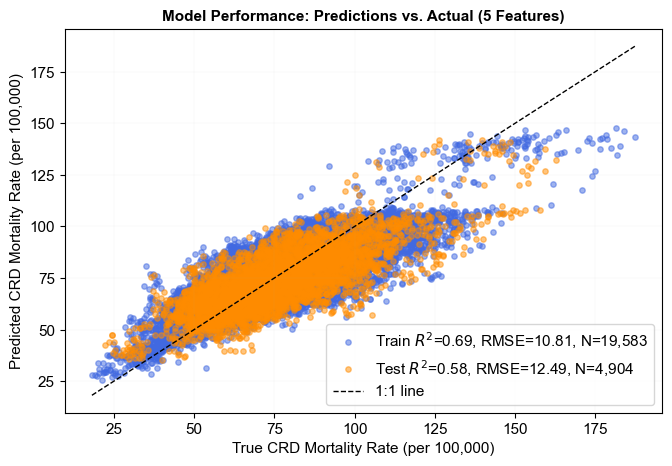

Figure 21: Scatter plot for top 5 features model.


In [132]:
fig, ax = plt.subplots(figsize=(DOUBLE_COL_WIDTH, DOUBLE_COL_WIDTH * 0.7))

ax.scatter(y_train, train_predictions_top5, color='royalblue',
           label=f'Train $R^2$={r2_train_top5:.2f}, RMSE={train_rmse_top5:.2f}, N={len(y_train):,}',
           alpha=0.5, s=15)
ax.scatter(y_test, test_predictions_top5, color='darkorange',
           label=f'Test $R^2$={r2_test_top5:.2f}, RMSE={test_rmse_top5:.2f}, N={len(y_test):,}',
           alpha=0.5, s=15)
ax.plot([y.min(), y.max()], [y.min(), y.max()],
        linestyle='--', color='black', linewidth=1, label='1:1 line')

ax.set_xlabel('True CRD Mortality Rate (per 100,000)', fontsize=FONT_SIZE)
ax.set_ylabel('Predicted CRD Mortality Rate (per 100,000)', fontsize=FONT_SIZE)
ax.set_title('Model Performance: Predictions vs. Actual (5 Features)',
             fontsize=FONT_SIZE, fontweight='bold')
ax.legend(fontsize=11, frameon=True, loc='lower right')
ax.grid(axis='both', linewidth=0.15, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{output_dir}fig21_scatter_performance_top5.png', dpi=DPI, bbox_inches='tight')
plt.show()
print("Figure 21: Scatter plot for top 5 features model.")

### 8.6 Figure 22: Q-Q Plot — Top 5 Features

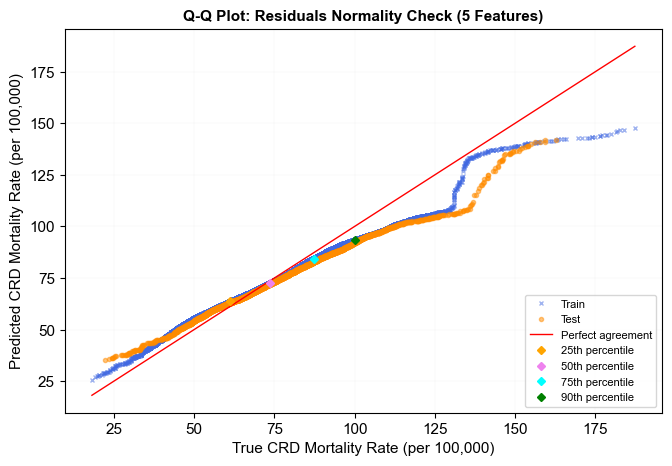

Figure 22: Q-Q plot for top 5 features model.


In [133]:
all_predictions_top5 = np.concatenate((train_predictions_top5, test_predictions_top5))

fig, ax = plt.subplots(figsize=(DOUBLE_COL_WIDTH, DOUBLE_COL_WIDTH * 0.7))

ax.plot(np.sort(y_train), np.sort(train_predictions_top5), 'x',
        label='Train', alpha=0.5, color='royalblue', markersize=3)
ax.plot(np.sort(y_test), np.sort(test_predictions_top5), 'o',
        label='Test', alpha=0.5, color='darkorange', markersize=3)
ax.plot([all_targets.min(), all_targets.max()], [all_targets.min(), all_targets.max()],
        'r', linewidth=1, label='Perfect agreement')

for percentile, color, label in [(25, 'orange', '25th'), (50, 'violet', '50th'),
                                   (75, 'cyan', '75th'), (90, 'green', '90th')]:
    target_pct = np.percentile(np.sort(all_targets), percentile)
    pred_pct   = np.percentile(np.sort(all_predictions_top5), percentile)
    ax.plot(target_pct, pred_pct, marker="D", markersize=4,
            color=color, linestyle='None', label=f"{label} percentile")

ax.set_title('Q-Q Plot: Residuals Normality Check (5 Features)',
             fontsize=FONT_SIZE, fontweight="bold")
ax.set_xlabel('True CRD Mortality Rate (per 100,000)', fontsize=FONT_SIZE)
ax.set_ylabel('Predicted CRD Mortality Rate (per 100,000)', fontsize=FONT_SIZE)
ax.grid(axis='both', linewidth=0.15, alpha=0.3)
ax.legend(fontsize=8, frameon=True, loc='lower right')

plt.tight_layout()
plt.savefig(f'{output_dir}fig22_qq_plot_top5.png', dpi=DPI, bbox_inches='tight')
plt.show()
print("Figure 22: Q-Q plot for top 5 features model.")

### 8.7 Calculate Permutation Importance

In [134]:
print("Calculating permutation importance for top 5 features...")
perm_importance_top5 = permutation_importance(best_model_top5, X_test_top5, y_test,
                                               n_repeats=10, random_state=42)
perm_importance_df_top5 = pd.DataFrame({
    'Feature':    X_test_top5.columns,
    'Importance': perm_importance_top5.importances_mean
}).sort_values(by='Importance', ascending=False)
print(f" Permutation importance calculated")

Calculating permutation importance for top 5 features...
 Permutation importance calculated


### 8.8 Figure 23: Permutation Importance — Top 5 Features

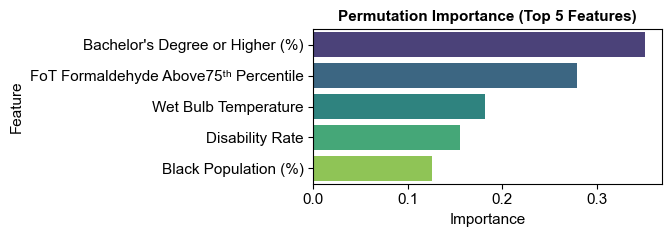

Figure 23: Permutation importance for top 5 features model.


In [135]:
fig, ax = plt.subplots(figsize=(DOUBLE_COL_WIDTH, 2.5))
sns.barplot(x='Importance', y='Feature', data=perm_importance_df_top5,
            palette='viridis', ax=ax)
ax.set_title('Permutation Importance (Top 5 Features)',
             fontsize=FONT_SIZE, fontweight='bold')
ax.set_xlabel('Importance', fontsize=FONT_SIZE)
ax.set_ylabel('Feature', fontsize=FONT_SIZE)
plt.tight_layout()
plt.savefig(f'{output_dir}fig23_permutation_importance_top5.png', dpi=DPI, bbox_inches='tight')
plt.show()
print("Figure 23: Permutation importance for top 5 features model.")

### 8.9 Compute SHAP Values

In [136]:
print("Computing SHAP values for top 5 features...")
explainer_top5   = shap.TreeExplainer(best_model_top5)
shap_values_top5 = explainer_top5.shap_values(X_test_top5)
print(f" SHAP values computed")

Computing SHAP values for top 5 features...
 SHAP values computed


### 8.10 Figure 24: SHAP Summary Plot — Top 5 Features

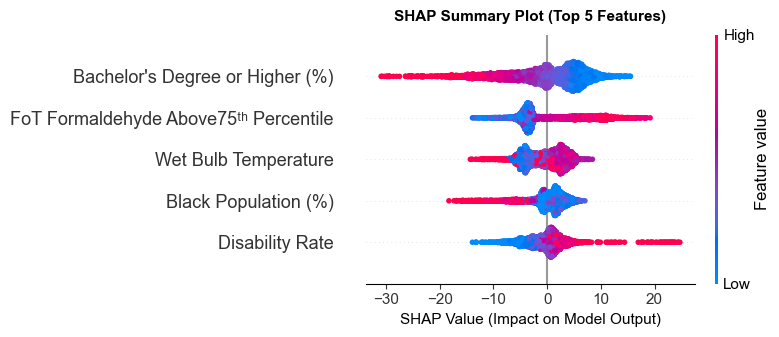

Figure 24: SHAP summary plot for top 5 features model.


In [137]:
plt.figure(figsize=(DOUBLE_COL_WIDTH, 3))
shap.summary_plot(shap_values_top5, X_test_top5, max_display=5, show=False)
plt.title('SHAP Summary Plot (Top 5 Features)',
          fontsize=FONT_SIZE, fontweight='bold', pad=10)
plt.xlabel('SHAP Value (Impact on Model Output)', fontsize=FONT_SIZE)
plt.tight_layout()
plt.savefig(f'{output_dir}fig24_shap_summary_top5.png', dpi=DPI, bbox_inches='tight')
plt.show()
print("Figure 24: SHAP summary plot for top 5 features model.")

### 8.11 Figure 25: SHAP Bar Plot — Top 5 Features

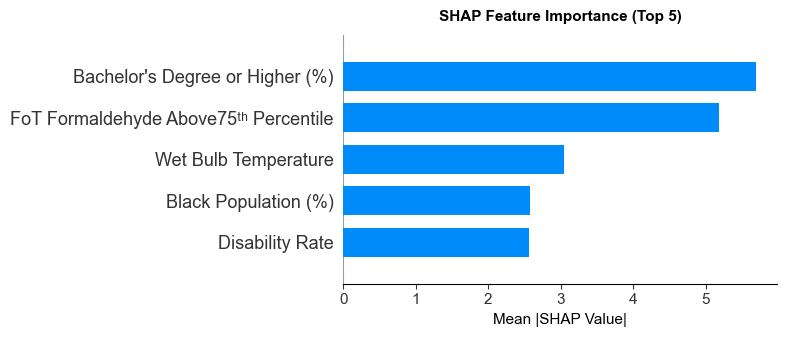

Figure 25: SHAP bar plot for top 5 features model.


In [138]:
plt.figure(figsize=(SINGLE_COL_WIDTH, 2.5))
shap.summary_plot(shap_values_top5, X_test_top5, plot_type="bar", max_display=5, show=False)
plt.title('SHAP Feature Importance (Top 5)',
          fontsize=FONT_SIZE, fontweight='bold', pad=10)
plt.xlabel('Mean |SHAP Value|', fontsize=FONT_SIZE)
plt.tight_layout()
plt.savefig(f'{output_dir}fig25_shap_bar_top5.png', dpi=DPI, bbox_inches='tight')
plt.show()
print("Figure 25: SHAP bar plot for top 5 features model.")

### 8.12 Identify Top 3 Features by SHAP

In [139]:
shap_importance_top5 = np.abs(shap_values_top5).mean(axis=0)
top_3_indices_top5  = np.argsort(shap_importance_top5)[-3:][::-1]
top_3_features_top5 = [X_test_top5.columns[i] for i in top_3_indices_top5]
print(f"Top 3 features for dependence plots: {top_3_features_top5}")

Top 3 features for dependence plots: ["Bachelor's Degree or Higher (%)", 'FoT Formaldehyde Above75ᵗʰ Percentile', 'Wet Bulb Temperature']


### 8.13 Figure 26: SHAP Dependence Plots — Top 5 Features

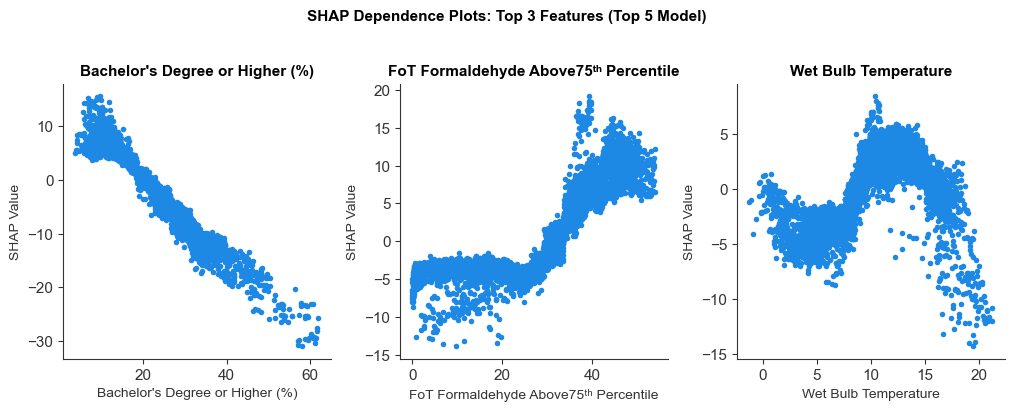

Figure 26: SHAP dependence plots for top 5 features model.


In [140]:
fig, axes = plt.subplots(1, 3, figsize=(DOUBLE_COL_WIDTH * 1.5, 4))

for idx, feature in enumerate(top_3_features_top5):
    shap.dependence_plot(feature, shap_values_top5, X_test_top5,
                         ax=axes[idx], show=False, interaction_index=None)
    axes[idx].set_title(f'{feature}', fontsize=FONT_SIZE, fontweight='bold')
    axes[idx].set_xlabel(feature, fontsize=FONT_SIZE - 1)
    axes[idx].set_ylabel('SHAP Value', fontsize=FONT_SIZE - 1)

plt.suptitle('SHAP Dependence Plots: Top 3 Features (Top 5 Model)',
             fontsize=FONT_SIZE, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{output_dir}fig26_shap_dependence_top5.png', dpi=DPI, bbox_inches='tight')
plt.show()
print("Figure 26: SHAP dependence plots for top 5 features model.")

## 9. Ablation Study

### 9.1 Compile Results Across All Models

In [141]:
ablation_data = {
    'Feature Set':  ['All Features', 'Top 20', 'Top 10', 'Top 5'],
    'Num Features': [X.shape[1], 20, 10, 5],
    'Train R²':     [r2_train, r2_train_top20, r2_train_top10, r2_train_top5],
    'Test R²':      [r2_test,  r2_test_top20,  r2_test_top10,  r2_test_top5],
    'Train RMSE':   [train_rmse, train_rmse_top20, train_rmse_top10, train_rmse_top5],
    'Test RMSE':    [test_rmse,  test_rmse_top20,  test_rmse_top10,  test_rmse_top5],
    'Train MAE':    [train_mae, train_mae_top20, train_mae_top10, train_mae_top5],
    'Test MAE':     [test_mae,  test_mae_top20,  test_mae_top10,  test_mae_top5],
}

ablation_df = pd.DataFrame(ablation_data)

print("=" * 70)
print("ABLATION STUDY: MODEL COMPARISON")
print("=" * 70)
display(ablation_df)

ablation_df.to_csv(f'{output_dir}table5_ablation_comparison.csv', index=False)
print(f"\n Ablation comparison saved to: {output_dir}table5_ablation_comparison.csv")

ABLATION STUDY: MODEL COMPARISON


,Feature Set,Num Features,Train R²,Test R²,Train RMSE,Test RMSE,Train MAE,Test MAE
0,All Features,43,0.967933,0.755039,3.495898,9.581919,2.645308,7.354571
1,Top 20,20,0.971612,0.738735,3.289233,9.895663,2.407739,7.638728
2,Top 10,10,0.879269,0.699583,6.783236,10.611250,5.173424,8.156667
3,Top 5,5,0.693659,0.583491,10.805115,12.494423,8.306063,9.764093



 Ablation comparison saved to: ../data/outputs/modeling/xgboost/table5_ablation_comparison.csv


### 9.2 Figure 28: Ablation Study Plot

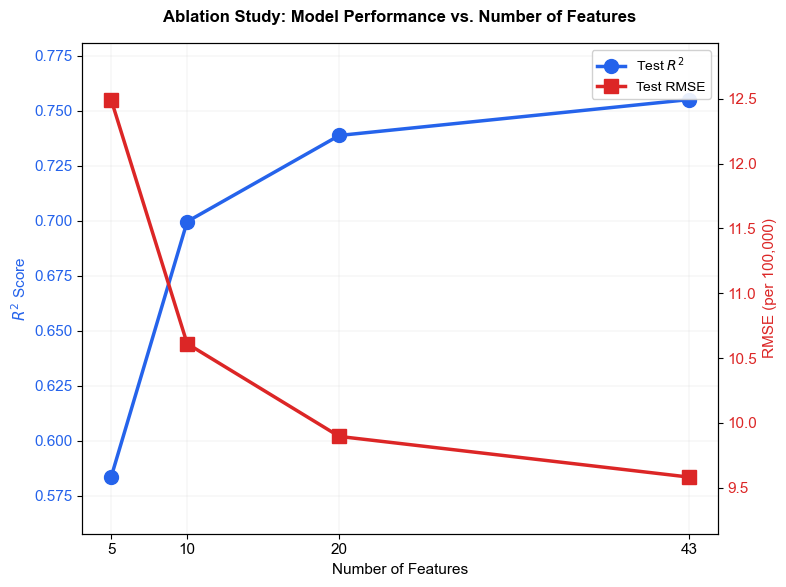

Figure 28: Ablation study showing performance vs. number of features.


In [142]:
fig, ax1 = plt.subplots(figsize=(8, 6))

color1 = '#2563eb'
ax1.set_xlabel('Number of Features', fontsize=FONT_SIZE)
ax1.set_ylabel('$R^2$ Score', color=color1, fontsize=FONT_SIZE)
line1 = ax1.plot(ablation_df['Num Features'], ablation_df['Test R²'],
                  marker='o', markersize=10, linewidth=2.5, color=color1, label='Test $R^2$')
ax1.tick_params(axis='y', labelcolor=color1)

r2_min = ablation_df['Test R²'].min()
r2_max = ablation_df['Test R²'].max()
r2_padding = (r2_max - r2_min) * 0.15
ax1.set_ylim([r2_min - r2_padding, min(1.0, r2_max + r2_padding)])
ax1.grid(axis='both', linewidth=0.3, alpha=0.4)

ax2 = ax1.twinx()
color2 = '#dc2626'
ax2.set_ylabel('RMSE (per 100,000)', color=color2, fontsize=FONT_SIZE)
line2 = ax2.plot(ablation_df['Num Features'], ablation_df['Test RMSE'],
                  marker='s', markersize=10, linewidth=2.5, color=color2, label='Test RMSE')
ax2.tick_params(axis='y', labelcolor=color2)

rmse_min = ablation_df['Test RMSE'].min()
rmse_max = ablation_df['Test RMSE'].max()
rmse_padding = (rmse_max - rmse_min) * 0.15
ax2.set_ylim([max(0, rmse_min - rmse_padding), rmse_max + rmse_padding])

ax1.set_title('Ablation Study: Model Performance vs. Number of Features',
              fontsize=FONT_SIZE + 1, fontweight='bold', pad=15)

lines  = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right', fontsize=FONT_SIZE - 1, framealpha=0.9)
ax1.set_xticks(ablation_df['Num Features'])
ax1.set_xticklabels(ablation_df['Num Features'].astype(int))

plt.tight_layout()
plt.savefig(f'{output_dir}fig28_ablation_study.png', dpi=DPI, bbox_inches='tight')
plt.show()
print("Figure 28: Ablation study showing performance vs. number of features.")

## 10. Summary

In [143]:
print("=" * 70)
print("NOTEBOOK COMPLETE")
print("=" * 70)
print(f"\nAll figures saved to: {output_dir}")
print(f"\nTest R² by model:")
print(f"  All Features: {r2_test:.4f}")
print(f"  Top 20:       {r2_test_top20:.4f}")
print(f"  Top 10:       {r2_test_top10:.4f}")
print(f"  Top 5:        {r2_test_top5:.4f}")
print("=" * 70)

NOTEBOOK COMPLETE

All figures saved to: ../data/outputs/modeling/xgboost/

Test R² by model:
  All Features: 0.7550
  Top 20:       0.7387
  Top 10:       0.6996
  Top 5:        0.5835
